# 🐱 Cat Pain LLM Evaluation
## Using GPT vision to classify cat behavior from video frames

This notebook evaluates cat pain-related behavior labels by sampling frames from each clip and asking a vision-capable LLM to classify behavior with structured reasoning.

It uses labeled records from `dataset/final_dataset.jsonl`, attaches top-3 prior predictions from the existing audio classifier output, and runs per-clip LLM inference with resume-safe JSONL logging.

Expected outputs include per-record predictions, confusion matrices, per-class metrics, confidence calibration plots, and a side-by-side comparison against existing model baselines.

In [1]:
import os
import json
import pathlib
import logging
import base64
import io
import time
import datetime
import re
from typing import Any

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
from tqdm.auto import tqdm as tqdm_auto
import openai
from openai import OpenAI
import cv2

from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score

sns.set_theme(style="whitegrid")

# =========================
# Config (user-facing only)
# =========================
MANIFEST_PATH = "dataset/final_dataset.jsonl"
VIDEO_BASE_DIR = ""  # user fills in if videos are local
FRAMES_PER_CLIP = 3
OPENAI_MODEL = "qwen/qwen3-vl-4b"
OPENAI_API_KEY = os.getenv("LM_STUDIO_API_KEY", "lm-studio")
OPENAI_BASE_URL = os.getenv("LM_STUDIO_BASE_URL", "http://127.0.0.1:1234/v1")
OUTPUT_JSONL = "runs/llm_eval_local/llm_predictions_qwen.jsonl"
MAX_SAMPLES = None  # set to integer to limit for testing
MAX_WORKERS = 1     # sequential local evaluation for Qwen
RANDOM_SEED = 42
LOG_LEVEL = logging.INFO

np.random.seed(RANDOM_SEED)

# Paths
PROJECT_ROOT = pathlib.Path.cwd()
MANIFEST_FILE = PROJECT_ROOT / MANIFEST_PATH
OUTPUT_FILE = PROJECT_ROOT / OUTPUT_JSONL
OUTPUT_DIR = OUTPUT_FILE.parent
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = OUTPUT_DIR / "eval.log"

# Logging setup
logger = logging.getLogger("cat_pain_llm_eval_local")
logger.setLevel(LOG_LEVEL)
logger.propagate = False

log_fmt = logging.Formatter("%(asctime)s │ %(levelname)s │ %(message)s")

if logger.handlers:
    logger.handlers.clear()

stream_handler = logging.StreamHandler()
stream_handler.setFormatter(log_fmt)
logger.addHandler(stream_handler)

file_handler = logging.FileHandler(LOG_FILE)
file_handler.setFormatter(log_fmt)
logger.addHandler(file_handler)

logger.info("Logger initialized")
logger.info(f"Manifest path: {MANIFEST_FILE}")
logger.info(f"Output JSONL: {OUTPUT_FILE}")

2026-04-07 19:34:44,160 │ INFO │ Logger initialized
2026-04-07 19:34:44,160 │ INFO │ Manifest path: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/dataset/final_dataset.jsonl
2026-04-07 19:34:44,161 │ INFO │ Output JSONL: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/runs/llm_eval_local/llm_predictions_qwen.jsonl


## Step 1 — Load Labeled Dataset

2026-04-07 19:34:44,206 │ INFO │ Removed 2 duplicate *_snip_<any_digit>_1 records
2026-04-07 19:34:44,317 │ INFO │ Loaded 715 new audio prior stems from: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/dataset/cleaned_labels.jsonl
2026-04-07 19:34:44,435 │ INFO │ Loaded 709 new audio prior stems from: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/human_validation_app/video_audio_human_validation/cat_emotion_predictions.jsonl


Preview (first 10 rows):


,stem,video_id,duration_sec,frame_count,pose_path,mean_pose_confidence,low_quality_pose,clip_path,label,label_confidence,logical_split,ml_split,top1_label,top1_prob,top2_label,top2_prob,top3_label,top3_prob
0,0qIYbl1HupM_snip_0,0qIYbl1HupM,6.812,35,dataset/embeddings/pose/labeled/0qIYbl1HupM_sn...,0.5636,False,dataset/embeddings/clip/labeled/0qIYbl1HupM_sn...,Paining,0.932101,labeled,train,Paining,0.932101,Happy,0.049308,Angry,1.660790e-02
2,0qIYbl1HupM_snip_3,0qIYbl1HupM,6.812,35,dataset/embeddings/pose/labeled/0qIYbl1HupM_sn...,0.4722,False,dataset/embeddings/clip/labeled/0qIYbl1HupM_sn...,Paining,0.864572,labeled,train,Paining,0.864572,Happy,0.133939,MotherCall,8.270268e-04
4,0qIYbl1HupM_snip_6,0qIYbl1HupM,6.011,31,dataset/embeddings/pose/labeled/0qIYbl1HupM_sn...,0.4657,False,dataset/embeddings/clip/labeled/0qIYbl1HupM_sn...,Positive_Baseline,0.989219,labeled,train,Happy,0.989219,Paining,0.010765,Fighting,6.688788e-06
5,0qIYbl1HupM_snip_9,0qIYbl1HupM,6.812,35,dataset/embeddings/pose/labeled/0qIYbl1HupM_sn...,0.8046,False,dataset/embeddings/clip/labeled/0qIYbl1HupM_sn...,Positive_Baseline,0.756566,labeled,train,Happy,0.756566,Paining,0.130298,MotherCall,4.099985e-02
6,1E54nUFWEfI_snip_0,1E54nUFWEfI,6.817,35,dataset/embeddings/pose/labeled/1E54nUFWEfI_sn...,0.7827,False,dataset/embeddings/clip/labeled/1E54nUFWEfI_sn...,Positive_Baseline,0.897252,labeled,val,Happy,0.897252,Paining,0.102687,Fighting,4.127775e-05
7,1E54nUFWEfI_snip_2,1E54nUFWEfI,5.817,30,dataset/embeddings/pose/labeled/1E54nUFWEfI_sn...,0.6665,False,dataset/embeddings/clip/labeled/1E54nUFWEfI_sn...,Paining,0.909239,labeled,val,Paining,0.909239,Happy,0.082740,MotherCall,7.830627e-03
8,1im3Hpv4NUA_snip_0,1im3Hpv4NUA,4.433,23,dataset/embeddings/pose/labeled/1im3Hpv4NUA_sn...,0.6340,False,dataset/embeddings/clip/labeled/1im3Hpv4NUA_sn...,Vocalizing,0.968337,labeled,val,MotherCall,0.968337,Paining,0.028486,Happy,2.974719e-03
9,1im3Hpv4NUA_snip_1,1im3Hpv4NUA,6.833,35,dataset/embeddings/pose/labeled/1im3Hpv4NUA_sn...,0.6445,False,dataset/embeddings/clip/labeled/1im3Hpv4NUA_sn...,Agonistic,0.743068,labeled,val,Fighting,0.743068,MotherCall,0.240917,Paining,9.291230e-03
10,29SmIf9Zqmo_snip_8,29SmIf9Zqmo,6.840,35,dataset/embeddings/pose/labeled/29SmIf9Zqmo_sn...,0.4079,False,dataset/embeddings/clip/labeled/29SmIf9Zqmo_sn...,Agonistic,0.969688,labeled,train,Angry,0.969688,Fighting,0.026352,Paining,1.795839e-03
11,5aAK5bu1KzE_snip_1,5aAK5bu1KzE,5.131,26,dataset/embeddings/pose/labeled/5aAK5bu1KzE_sn...,0.3380,False,dataset/embeddings/clip/labeled/5aAK5bu1KzE_sn...,Vocalizing,0.999958,labeled,train,MotherCall,0.999958,Paining,0.000042,Happy,3.646535e-07



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 663 entries, 0 to 664
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   stem                  663 non-null    object 
 1   video_id              663 non-null    object 
 2   duration_sec          663 non-null    float64
 3   frame_count           663 non-null    int64  
 4   pose_path             663 non-null    object 
 5   mean_pose_confidence  663 non-null    float64
 6   low_quality_pose      663 non-null    bool   
 7   clip_path             663 non-null    object 
 8   label                 663 non-null    object 
 9   label_confidence      663 non-null    float64
 10  logical_split         663 non-null    object 
 11  ml_split              663 non-null    object 
 12  top1_label            663 non-null    object 
 13  top1_prob             589 non-null    float64
 14  top2_label            663 non-null    object 
 15  top2_prob  

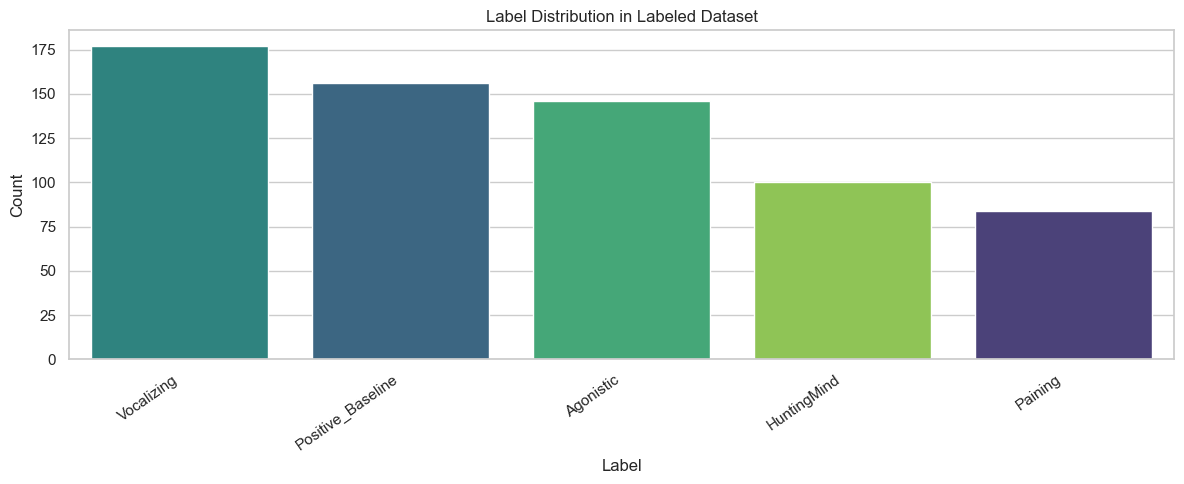

Loaded 663 labeled records across 5 classes
Removed duplicate *_snip_<any_digit>_1 rows: 2

Top-3 attached probabilities preview:


,stem,top1_label,top1_prob,top2_label,top2_prob,top3_label,top3_prob
0,0qIYbl1HupM_snip_0,Paining,0.932101,Happy,0.049308,Angry,1.660790e-02
2,0qIYbl1HupM_snip_3,Paining,0.864572,Happy,0.133939,MotherCall,8.270268e-04
4,0qIYbl1HupM_snip_6,Happy,0.989219,Paining,0.010765,Fighting,6.688788e-06
5,0qIYbl1HupM_snip_9,Happy,0.756566,Paining,0.130298,MotherCall,4.099985e-02
6,1E54nUFWEfI_snip_0,Happy,0.897252,Paining,0.102687,Fighting,4.127775e-05
7,1E54nUFWEfI_snip_2,Paining,0.909239,Happy,0.082740,MotherCall,7.830627e-03
8,1im3Hpv4NUA_snip_0,MotherCall,0.968337,Paining,0.028486,Happy,2.974719e-03
9,1im3Hpv4NUA_snip_1,Fighting,0.743068,MotherCall,0.240917,Paining,9.291230e-03
10,29SmIf9Zqmo_snip_8,Angry,0.969688,Fighting,0.026352,Paining,1.795839e-03
11,5aAK5bu1KzE_snip_1,MotherCall,0.999958,Paining,0.000042,Happy,3.646535e-07


In [2]:
def _to_stem(value: Any) -> str | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    s = str(value).strip()
    if not s:
        return None
    return pathlib.Path(s).stem


def infer_stem_from_row(row: pd.Series) -> str:
    candidate_cols = [
        "stem", "video_stem", "clip_stem", "file_stem",
        "video_path", "clip_path", "filepath", "file_path", "path",
        "video_file", "video", "filename", "source_path"
    ]
    for c in candidate_cols:
        if c in row.index:
            stem = _to_stem(row[c])
            if stem:
                return stem
    return f"row_{row.name}"


def extract_top3_from_prediction_row(row: dict) -> list[tuple[str, float]]:
    dict_candidates = [
        "class_probabilities", "label_probabilities", "probabilities",
        "probs", "scores", "prediction_probs", "predictions"
    ]
    for key in dict_candidates:
        if key in row and isinstance(row[key], dict):
            items = [(str(k), float(v)) for k, v in row[key].items() if v is not None]
            items = sorted(items, key=lambda x: x[1], reverse=True)
            if items:
                return (items + [("NA", np.nan)] * 3)[:3]

    list_candidates = ["top_k", "top3", "ranked_predictions", "predictions"]
    for key in list_candidates:
        if key in row and isinstance(row[key], list) and len(row[key]) > 0:
            parsed = []
            for item in row[key]:
                if isinstance(item, dict):
                    lbl = item.get("label") or item.get("class") or item.get("name")
                    prob = item.get("prob") or item.get("score") or item.get("confidence")
                    if lbl is not None and prob is not None:
                        try:
                            parsed.append((str(lbl), float(prob)))
                        except Exception:
                            pass
            parsed = sorted(parsed, key=lambda x: x[1], reverse=True)
            if parsed:
                return (parsed + [("NA", np.nan)] * 3)[:3]

    # cleaned_labels.jsonl schema: prob_<Label> columns
    prob_cols = [k for k in row.keys() if str(k).startswith("prob_")]
    if prob_cols:
        parsed = []
        for c in prob_cols:
            lbl = str(c).replace("prob_", "", 1)
            val = row.get(c)
            try:
                parsed.append((lbl, float(val)))
            except Exception:
                continue
        parsed = sorted(parsed, key=lambda x: x[1], reverse=True)
        if parsed:
            return (parsed + [("NA", np.nan)] * 3)[:3]

    fallback = []
    for i in [1, 2, 3]:
        lbl = row.get(f"top{i}_label")
        prob = row.get(f"top{i}_prob")
        if lbl is not None:
            try:
                fallback.append((str(lbl), float(prob) if prob is not None else np.nan))
            except Exception:
                fallback.append((str(lbl), np.nan))
    if fallback:
        return (fallback + [("NA", np.nan)] * 3)[:3]

    return [("NA", np.nan), ("NA", np.nan), ("NA", np.nan)]


if not MANIFEST_FILE.exists():
    raise FileNotFoundError(f"Manifest not found: {MANIFEST_FILE}")

raw_df = pd.read_json(MANIFEST_FILE, lines=True)
if "logical_split" in raw_df.columns:
    df = raw_df.loc[raw_df["logical_split"] == "labeled"].copy()
else:
    logger.warning("Column 'logical_split' not found; using full dataset")
    df = raw_df.copy()

df["stem"] = df.apply(infer_stem_from_row, axis=1)

# Remove duplicate variants like *_snip_X_1 when *_snip_X also exists.
df["stem_base"] = df["stem"].str.replace(r"_1$", "", regex=True)
base_stems = set(df["stem_base"].tolist())
is_suffix_dup = df["stem"].str.contains(r"_snip_\d+_1$", regex=True, na=False)
has_base_counterpart = df["stem"].str.replace(r"_1$", "", regex=True).isin(base_stems)
remove_mask = is_suffix_dup & has_base_counterpart
removed_dupes = int(remove_mask.sum())
df = df.loc[~remove_mask].copy()
df = df.drop(columns=["stem_base"])
logger.info(f"Removed {removed_dupes} duplicate *_snip_<any_digit>_1 records")

pred_candidates = [
    PROJECT_ROOT / "dataset/cleaned_labels.jsonl",
    PROJECT_ROOT / "human_validation_app/video_audio_human_validation/cat_emotion_predictions.jsonl",
]
existing_pred_files = [p for p in pred_candidates if p.exists()]

pred_map = {}
if existing_pred_files:
    for pred_file in existing_pred_files:
        preds_raw = pd.read_json(pred_file, lines=True)
        if "stem" not in preds_raw.columns:
            preds_raw["stem"] = preds_raw.apply(
                lambda r: infer_stem_from_row(pd.Series(r.to_dict())), axis=1
            )
        loaded_this_file = 0
        for _, r in preds_raw.iterrows():
            rec = r.to_dict()
            stem = rec.get("stem")
            if stem:
                # keep first source priority (cleaned_labels first), fill gaps from later files
                if str(stem) not in pred_map:
                    pred_map[str(stem)] = extract_top3_from_prediction_row(rec)
                    loaded_this_file += 1
        logger.info(f"Loaded {loaded_this_file} new audio prior stems from: {pred_file}")
else:
    logger.warning(f"No predictions file found in candidates: {pred_candidates}")

attached = df["stem"].map(lambda s: pred_map.get(str(s), [("NA", np.nan)] * 3))
df["top1_label"] = attached.map(lambda x: x[0][0])
df["top1_prob"] = attached.map(lambda x: x[0][1])
df["top2_label"] = attached.map(lambda x: x[1][0])
df["top2_prob"] = attached.map(lambda x: x[1][1])
df["top3_label"] = attached.map(lambda x: x[2][0])
df["top3_prob"] = attached.map(lambda x: x[2][1])

print("Preview (first 10 rows):")
display(df.head(10))

print("\nDataFrame info:")
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())

label_col = "label" if "label" in df.columns else ("label_original" if "label_original" in df.columns else None)
if label_col is None:
    raise KeyError("Could not find label column. Expected 'label' or 'label_original'.")

order = df[label_col].value_counts().sort_values(ascending=False).index
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x=label_col, order=order, hue=label_col, dodge=False, palette="viridis", legend=False)
plt.title("Label Distribution in Labeled Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print(f"Loaded {len(df)} labeled records across {df[label_col].nunique()} classes")
print(f"Removed duplicate *_snip_<any_digit>_1 rows: {removed_dupes}")

print("\nTop-3 attached probabilities preview:")
display(df[["stem", "top1_label", "top1_prob", "top2_label", "top2_prob", "top3_label", "top3_prob"]].head(10))

## Step 2 — Frame Extraction: Strategy & Example

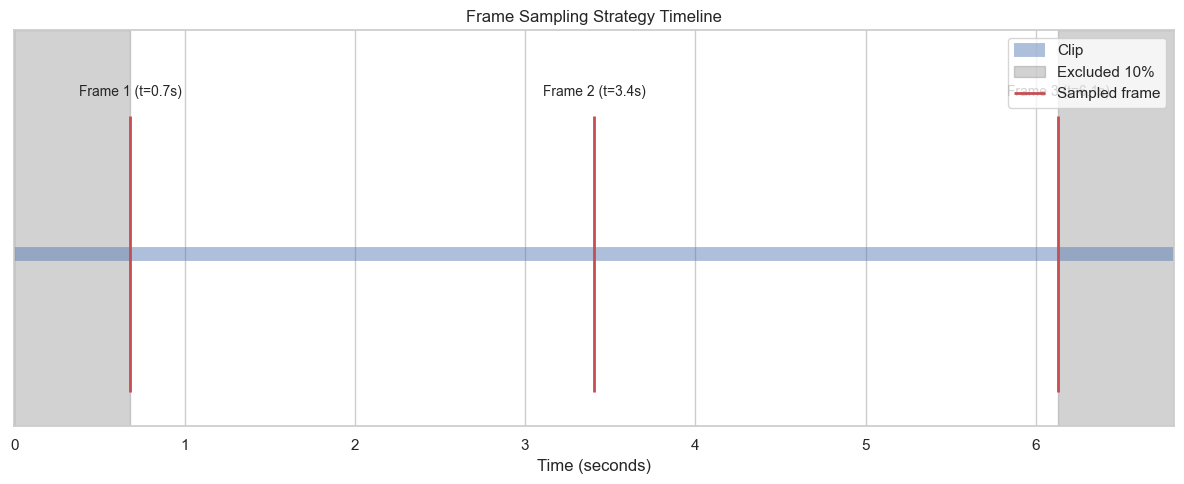

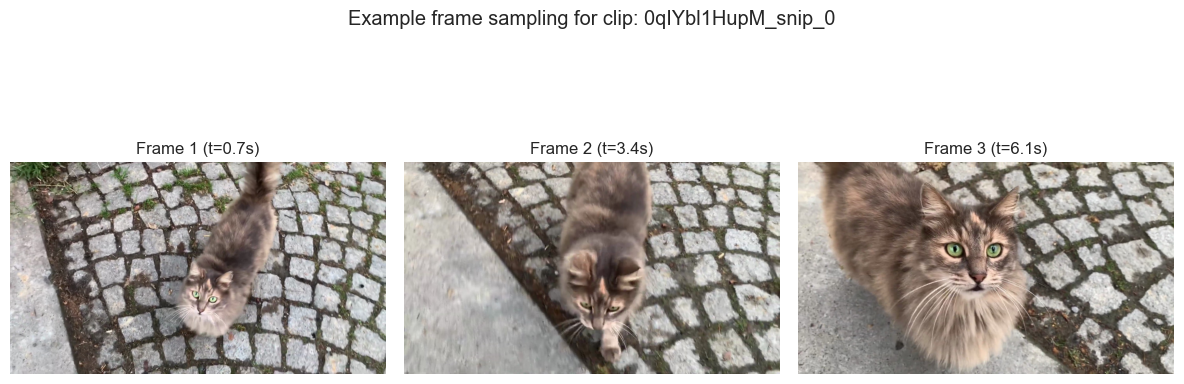

Frame sampling strategy: 3 uniform samples in [10%, 90%] of clip duration


In [3]:
def get_frame_timestamps(n_frames: int, duration_sec: float, n_samples: int = 3) -> list[float]:
    """Sample n_samples frame timestamps uniformly across the clip.
    Returns timestamps in seconds, avoiding first and last 10% of clip
    to skip intro/outro artifacts."""
    duration = float(duration_sec) if duration_sec and duration_sec > 0 else 1.0
    start = 0.1 * duration
    end = 0.9 * duration
    if n_samples <= 1:
        return [round((start + end) / 2.0, 3)]
    ts = np.linspace(start, end, n_samples)
    return [round(float(x), 3) for x in ts]


def extract_frames_from_video(video_path: str, timestamps_sec: list[float]) -> list[np.ndarray]:
    """Extract frames at given timestamps.

    Supports:
    - video files via cv2.VideoCapture
    - frame directories (`frame_XXXX.jpg`) under `dataset/frames`

    Returns list of RGB numpy arrays. Returns empty list if source is missing.
    """
    p = pathlib.Path(video_path)
    if not p.exists():
        return []

    # Never attempt to decode embeddings as videos.
    if p.suffix.lower() == ".npz" or "embeddings" in p.as_posix():
        return []

    # If path points to extracted frame directory, sample nearest jpg frames.
    if p.is_dir():
        frame_files = sorted(p.glob("frame_*.jpg"))
        if not frame_files:
            return []

        # Try to infer duration from meta.json; fallback to frame count at 30 fps.
        meta_path = p / "meta.json"
        duration = None
        if meta_path.exists():
            try:
                meta = json.loads(meta_path.read_text(encoding="utf-8"))
                duration = meta.get("duration_sec")
                if duration is not None:
                    duration = float(duration)
            except Exception:
                duration = None
        if duration is None or duration <= 0:
            duration = max(len(frame_files) / 30.0, 1.0)

        sampled = []
        for t in timestamps_sec:
            frac = float(t) / duration if duration > 0 else 0.0
            frac = min(max(frac, 0.0), 1.0)
            idx = int(round(frac * (len(frame_files) - 1)))
            img = Image.open(frame_files[idx]).convert("RGB")
            sampled.append(np.array(img))
        return sampled

    cap = cv2.VideoCapture(str(p))
    if not cap.isOpened():
        return []
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frames = []
    for t in timestamps_sec:
        frame_idx = max(0, int(round(float(t) * fps)))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame_bgr = cap.read()
        if not ok or frame_bgr is None:
            continue
        frames.append(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def load_frame_from_pose_npy(pose_path: str, frame_indices: list[int]) -> list[np.ndarray] | None:
    """Fallback: if no video available, return None (will use placeholder)."""
    return None


def resolve_video_path(record: pd.Series) -> pathlib.Path | None:
    # Prefer real media/frames; never use embedding artifacts (e.g., *.npz).
    def _usable_media_path(p: pathlib.Path) -> bool:
        if not p.exists():
            return False
        if p.suffix.lower() == ".npz":
            return False
        if "embeddings" in p.as_posix():
            return False
        return True

    for col in ["video_path", "clip_path", "filepath", "file_path", "path", "video_file", "video", "filename"]:
        if col in record.index and pd.notna(record[col]):
            p = pathlib.Path(str(record[col]))
            if _usable_media_path(p):
                return p
            if VIDEO_BASE_DIR:
                q = pathlib.Path(VIDEO_BASE_DIR) / p
                if _usable_media_path(q):
                    return q

    stem = str(record.get("stem", ""))
    if not stem:
        return None

    # Primary fallback: extracted frames directory.
    split = str(record.get("logical_split", "labeled"))
    frames_dir = PROJECT_ROOT / "dataset" / "frames" / split / stem
    if frames_dir.exists() and frames_dir.is_dir():
        return frames_dir

    roots = [
        pathlib.Path(VIDEO_BASE_DIR) if VIDEO_BASE_DIR else None,
        PROJECT_ROOT / "human_validation_app" / "video_audio_human_validation" / "cat",
        PROJECT_ROOT / "dataset_snippets",
        PROJECT_ROOT / "downloaded_snippets",
    ]
    roots = [r for r in roots if r is not None]
    for root in roots:
        for ext in [".mp4", ".mov", ".avi", ".mkv", ".webm"]:
            c = root / f"{stem}{ext}"
            if _usable_media_path(c):
                return c

    return None


def _get_duration_and_frames(video_path: pathlib.Path | None, record: pd.Series) -> tuple[float, int]:
    duration = None
    for c in ["duration_sec", "duration", "clip_duration", "video_duration"]:
        if c in record.index and pd.notna(record[c]):
            try:
                duration = float(record[c])
                break
            except Exception:
                pass
    n_frames = None
    for c in ["frame_count", "n_frames", "frames", "num_frames"]:
        if c in record.index and pd.notna(record[c]):
            try:
                n_frames = int(record[c])
                break
            except Exception:
                pass
    if video_path is not None and video_path.exists() and video_path.is_file():
        cap = cv2.VideoCapture(str(video_path))
        if cap.isOpened():
            fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
            vf = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
            if n_frames is None and vf > 0:
                n_frames = vf
            if duration is None and fps > 0 and vf > 0:
                duration = vf / fps
        cap.release()

    # If source is a frames directory, derive stats from its files and meta.json.
    if video_path is not None and video_path.exists() and video_path.is_dir():
        frame_files = sorted(video_path.glob("frame_*.jpg"))
        if n_frames is None and frame_files:
            n_frames = len(frame_files)
        meta_path = video_path / "meta.json"
        if (duration is None or duration <= 0) and meta_path.exists():
            try:
                meta = json.loads(meta_path.read_text(encoding="utf-8"))
                meta_duration = float(meta.get("duration_sec", 0.0) or 0.0)
                if meta_duration > 0:
                    duration = meta_duration
            except Exception:
                pass
    if duration is None or duration <= 0:
        duration = 3.0
    if n_frames is None or n_frames <= 0:
        n_frames = int(duration * 30)
    return float(duration), int(n_frames)


def _placeholder_frame(label: str, width: int = 360, height: int = 240) -> np.ndarray:
    img = np.full((height, width, 3), 180, dtype=np.uint8)
    cv2.putText(img, label, (20, height // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (70, 70, 70), 2, cv2.LINE_AA)
    return img

# Visualization
example = df.iloc[0]
example_stem = str(example.get("stem", "example_clip"))
example_video = resolve_video_path(example)
duration_sec, frame_count = _get_duration_and_frames(example_video, example)
timestamps = get_frame_timestamps(frame_count, duration_sec, n_samples=FRAMES_PER_CLIP)

plt.figure(figsize=(12, 5))
plt.hlines(1, 0, duration_sec, linewidth=10, color="#4C72B0", alpha=0.45, label="Clip")
plt.axvspan(0, 0.1 * duration_sec, color="gray", alpha=0.35, label="Excluded 10%")
plt.axvspan(0.9 * duration_sec, duration_sec, color="gray", alpha=0.35)
for i, t in enumerate(timestamps, start=1):
    plt.vlines(t, 0.6, 1.4, color="#C44E52", linewidth=2, label="Sampled frame" if i == 1 else None)
    plt.text(t, 1.45, f"Frame {i} (t={t:.1f}s)", ha="center", va="bottom", fontsize=10)
plt.yticks([])
plt.xlabel("Time (seconds)")
plt.title("Frame Sampling Strategy Timeline")
plt.legend(loc="upper right")
plt.xlim(0, max(duration_sec, 1.0))
plt.ylim(0.5, 1.65)
plt.tight_layout()
plt.show()

frames = extract_frames_from_video(str(example_video), timestamps) if example_video is not None else []
if len(frames) < FRAMES_PER_CLIP:
    frames = frames + [_placeholder_frame(f"No video\nt={timestamps[i]:.1f}s") for i in range(len(frames), FRAMES_PER_CLIP)]

fig, axes = plt.subplots(1, FRAMES_PER_CLIP, figsize=(12, 5))
if FRAMES_PER_CLIP == 1:
    axes = [axes]
for i, (ax, img) in enumerate(zip(axes, frames), start=1):
    ax.imshow(img)
    ax.set_title(f"Frame {i} (t={timestamps[i-1]:.1f}s)")
    ax.axis("off")
fig.suptitle(f"Example frame sampling for clip: {example_stem}")
plt.tight_layout()
plt.show()

print("Frame sampling strategy: 3 uniform samples in [10%, 90%] of clip duration")

## Step 3 — System Prompt & LLM Prompting Strategy

In [4]:
SYSTEM_PROMPT = """
You are a veterinary pain assessment assistant trained in the Feline 
Grimace Scale (FGS), developed and validated by the Université de 
Montréal (© 2019) for acute pain assessment in cats.

You will receive three video frames sampled uniformly from a short cat 
video clip. Your task is to apply the FGS to each frame independently, 
then produce a consensus assessment across all three frames.

════════════════════════════════════════════════════════════
THE FELINE GRIMACE SCALE — SCORING GUIDE
════════════════════════════════════════════════════════════

Score each of the 5 action units from 0 to 2:
  0 = absent
  1 = moderately present or uncertain
  2 = markedly present / obviously present

──────────────────────────────────────────
ACTION UNIT 1 — EAR POSITION
──────────────────────────────────────────
0 = Ears facing forward (neutral, relaxed)
1 = Ears slightly pulled apart from neutral position
2 = Ears rotated outwards and flattened (airplane ears)

──────────────────────────────────────────
ACTION UNIT 2 — ORBITAL TIGHTENING
──────────────────────────────────────────
0 = Eyes fully open
1 = Eyes partially closed (half-closed)
2 = Eyes squinted or nearly shut

──────────────────────────────────────────
ACTION UNIT 3 — MUZZLE TENSION
──────────────────────────────────────────
0 = Muzzle relaxed, round shape
1 = Mild tension visible around muzzle
2 = Muzzle tense, elliptical or elongated shape

──────────────────────────────────────────
ACTION UNIT 4 — WHISKERS CHANGE
──────────────────────────────────────────
0 = Whiskers loose, relaxed and curved naturally
1 = Whiskers slightly curved or straight, closer together
2 = Whiskers straight, stiff and pointing forward (rostrally)

──────────────────────────────────────────
ACTION UNIT 5 — HEAD POSITION
──────────────────────────────────────────
0 = Head above the shoulder line (alert, upright)
1 = Head aligned with the shoulder line
2 = Head below the shoulder line, or tilted downward 
    (chin toward chest)

════════════════════════════════════════════════════════════
SCORE INTERPRETATION
════════════════════════════════════════════════════════════
Total score = sum of all 5 action units (max = 10)

  0     → No pain
  1–3   → No pain or mild pain (monitor, reassess)
  4–8   → Likely in pain — analgesia should be considered
  9–10  → Likely in severe pain — analgesia strongly indicated

The clinical cut-off for analgesia administration is a score of 4.

════════════════════════════════════════════════════════════
IMPORTANT CAVEATS — READ BEFORE SCORING
════════════════════════════════════════════════════════════
1. The FGS is validated for ACUTE pain only. It is not reliable 
   for chronic conditions.

2. Do NOT score the cat if it is currently grooming, sleeping, 
   playing or eating. If any frame shows this, note it and rely 
   on the other frames.

3. High FGS scores can result from stress, fear or sedation — 
   not only pain. Note this uncertainty in your reasoning if the 
   context suggests non-pain causes (e.g. vet clinic environment, 
   restraint, other cats nearby).

4. You are working from still frames, not live observation. 
   Acknowledge any visibility limitations (blur, occlusion, 
   camera angle, low resolution) that prevent reliable scoring 
   of specific action units. Score those units as 1 (uncertain) 
   rather than guessing.

5. Score each frame independently first, then produce a consensus 
   score by taking the maximum observed score per action unit 
   across all three frames (conservative approach — if pain was 
   present in any frame, it counts).

════════════════════════════════════════════════════════════
BEHAVIORAL CONTEXT LABELS
════════════════════════════════════════════════════════════
Beyond the FGS score, classify the cat's overall behavioral state 
into EXACTLY ONE of these five categories:

  Paining           — Pain indicators present (FGS score ≥ 4, 
                       hunched posture, orbital tightening, 
                       withdrawn or tense body)

  Positive_Baseline — Calm, relaxed, content. Includes resting, 
                       sleeping, slow blinking, comfortable posture. 
                       (Merges: Happy + Resting)

  Agonistic         — Aggressive or defensive behavior. Includes 
                       hissing, arched back, piloerection, flattened 
                       ears in threat context, active fighting or 
                       cornered defensive crouch.
                       (Merges: Angry + Fighting + Defence)

  Vocalizing        — Prominent vocalization-driven behavior. Includes 
                       yowling, calling, mating calls, warning cries, 
                       mouth open in sustained vocalization.
                       (Merges: Mating + Warning + MotherCall)

  HuntingMind       — Stalking, crouching with intense visual focus, 
                       chattering at prey, predatory stillness.

You MUST output exactly one of these five strings as behavioral_label:
  "Paining" | "Positive_Baseline" | "Agonistic" | "Vocalizing" | "HuntingMind"

Do not output any other label name.

════════════════════════════════════════════════════════════
OUTPUT FORMAT — MANDATORY
════════════════════════════════════════════════════════════
You MUST respond with a single valid JSON object and nothing else.
No markdown, no explanation outside the JSON, no code fences.

{
  "frame_scores": [
    {
      "frame_index": 0,
      "ear_position": 0,
      "orbital_tightening": 0,
      "muzzle_tension": 0,
      "whiskers_change": 0,
      "head_position": 0,
      "frame_total": 0,
      "visibility_issues": "none | brief description if any"
    },
    { "frame_index": 1, ... },
    { "frame_index": 2, ... }
  ],
  "consensus": {
    "ear_position": 0,
    "orbital_tightening": 0,
    "muzzle_tension": 0,
    "whiskers_change": 0,
    "head_position": 0,
    "fgs_total": 0,
    "fgs_interpretation": "No pain | Mild pain | Likely pain | Severe pain",
    "pain_binary": "Pain | No_Pain",
    "behavioral_label": "one of the 5 labels above",
    "confidence": "high | medium | low",
    "confidence_reason": "brief explanation of what drove confidence level",
    "reasoning": "2-4 sentences describing the key visual evidence that 
                  drove your scoring, referencing specific action units 
                  and frames. Note any stress/fear confounds if present."
  }
}

If you cannot assess a frame at all (fully occluded cat, no cat visible),
set all scores for that frame to -1 and explain in visibility_issues.
"""

def build_user_prompt(record: dict, frame_timestamps: list[float]) -> str:
    """Build user-facing prompt for one clip using FGS + behavioral context schema."""
    duration = record.get("duration_sec") or record.get("duration") or record.get("clip_duration") or "unknown"
    frame_count = record.get("frame_count") or record.get("n_frames") or record.get("frames") or "unknown"
    stem = record.get("stem", "unknown_stem")

    prompt = f"""
You are evaluating a short cat behavior clip from three sampled still frames.

Clip metadata:
- stem: {stem}
- duration_sec: {duration}
- frame_count: {frame_count}
- sampled_frame_timestamps_sec: {frame_timestamps}

Instructions:
1) Score each frame independently with the 5 FGS action units.
2) Build consensus by taking max score per action unit across frames.
3) Derive fgs_total and pain_binary with cut-off >= 4 as Pain.
4) Predict one behavioral_label from the allowed 5 merged labels.
5) Return strict JSON only with the exact schema defined in system prompt.
""".strip()
    return prompt


example_record = df.iloc[0].to_dict()
example_duration = example_record.get("duration_sec") or example_record.get("duration") or 3.0
example_frames = int(example_record.get("frame_count") or example_record.get("n_frames") or 90)
example_ts = get_frame_timestamps(example_frames, float(example_duration), FRAMES_PER_CLIP)
example_prompt = build_user_prompt(example_record, example_ts)

display(Markdown("### Rendered Example Prompt"))
display(Markdown(f"```text\n{example_prompt}\n```"))

char_count = len(example_prompt)
est_tokens = int(np.ceil(char_count / 4))
print(f"Character count: {char_count}")
print(f"Estimated token count (chars/4): {est_tokens}")


### Rendered Example Prompt

```text
You are evaluating a short cat behavior clip from three sampled still frames.

Clip metadata:
- stem: 0qIYbl1HupM_snip_0
- duration_sec: 6.812
- frame_count: 35
- sampled_frame_timestamps_sec: [0.681, 3.406, 6.131]

Instructions:
1) Score each frame independently with the 5 FGS action units.
2) Build consensus by taking max score per action unit across frames.
3) Derive fgs_total and pain_binary with cut-off >= 4 as Pain.
4) Predict one behavioral_label from the allowed 5 merged labels.
5) Return strict JSON only with the exact schema defined in system prompt.
```

Character count: 566
Estimated token count (chars/4): 142


## Step 4 — OpenAI API Call & Response Parsing

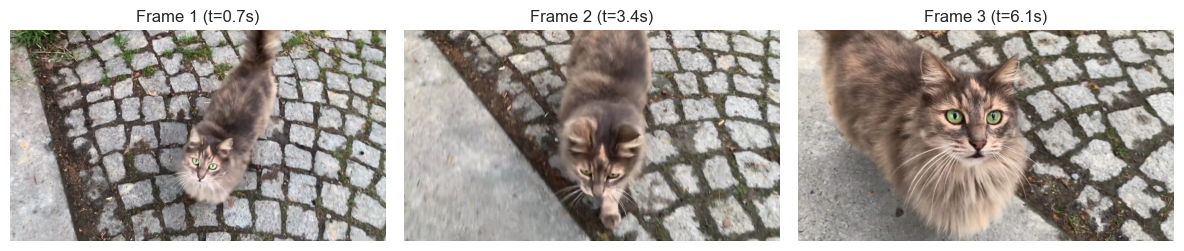

### Prompt Sent (abbreviated)

```text
You are evaluating a short cat behavior clip from three sampled still frames.

Clip metadata:
- stem: 0qIYbl1HupM_snip_0
- duration_sec: 6.812
- frame_count: 35
- sampled_frame_timestamps_sec: [0.681, 3.406, 6.131]

Instructions:
1) Score each frame independently with the 5 FGS action units.
2) Build consensus by taking max score per action unit across frames.
3) Derive fgs_total and pain_binary with cut-off >= 4 as Pain.
4) Predict one behavioral_label from the allowed 5 merged labels.
5) Return strict JSON only with the exact schema defined in system prompt.
```

Raw response:
{
  "frame_scores": [
    {
      "frame_index": 0,
      "ear_position": 0,
      "orbital_tightening": 0,
      "muzzle_tension": 0,
      "whiskers_change": 0,
      "head_position": 0,
      "frame_total": 0,
      "visibility_issues": "none"
    },
    {
      "frame_index": 1,
      "ear_position": 0,
      "orbital_tightening": 0,
      "muzzle_tension": 0,
      "whiskers_change": 0,
      "head_position": 0,
      "frame_total": 0,
      "visibility_issues": "none"
    },
    {
      "frame_index": 2,
      "ear_position": 0,
      "orbital_tightening": 0,
      "muzzle_tension": 0,
      "whiskers_change": 0,
      "head_position": 0,
      "frame_total": 0,
      "visibility_issues": "none"
    }
  ],
  "consensus": {
    "ear_position": 0,
    "orbital_tightening": 0,
    "muzzle_tension": 0,
    "whiskers_change": 0,
    "head_position": 0,
    "fgs_total": 0,
    "fgs_interpretation": "No pain",
    "pain_binary": "No_Pain",
    "behavioral_label": "Positive

In [5]:
def encode_image_to_base64(image_array: np.ndarray) -> str:
    """Convert RGB numpy array to base64 JPEG string for API."""
    image = Image.fromarray(image_array.astype(np.uint8))
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=90)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


def parse_llm_response(raw: str) -> dict:
    """Parse FGS JSON response with graceful fallback."""
    parsed = {
        "frame_scores": [],
        "consensus": {},
        "predicted_label": "Unknown",
        "pain_binary": "Unknown",
        "confidence": "low",
        "reasoning": "",
        "questionnaire_scores": {},
        "parse_error": False,
    }

    if raw is None:
        parsed["parse_error"] = True
        return parsed

    text = str(raw).strip()

    def _coerce(obj: dict) -> dict:
        consensus = obj.get("consensus", {}) if isinstance(obj, dict) else {}
        frame_scores = obj.get("frame_scores", []) if isinstance(obj, dict) else []
        if not isinstance(consensus, dict):
            consensus = {}
        if not isinstance(frame_scores, list):
            frame_scores = []

        behavioral = str(consensus.get("behavioral_label", "Unknown"))
        pain_binary = str(consensus.get("pain_binary", "Pain" if str(behavioral).strip().lower() in {"paining", "pain"} else "No_Pain"))
        confidence = str(consensus.get("confidence", "low"))
        reasoning = str(consensus.get("reasoning", ""))

        q_scores = {
            "ear_position": consensus.get("ear_position"),
            "orbital_tightening": consensus.get("orbital_tightening"),
            "muzzle_tension": consensus.get("muzzle_tension"),
            "whiskers_change": consensus.get("whiskers_change"),
            "head_position": consensus.get("head_position"),
            "fgs_total": consensus.get("fgs_total"),
            "fgs_interpretation": consensus.get("fgs_interpretation"),
            "confidence_reason": consensus.get("confidence_reason"),
        }

        return {
            "frame_scores": frame_scores,
            "consensus": consensus,
            "predicted_label": behavioral,
            "pain_binary": pain_binary,
            "confidence": confidence,
            "reasoning": reasoning,
            "questionnaire_scores": q_scores,
            "parse_error": False,
        }

    try:
        obj = json.loads(text)
        parsed.update(_coerce(obj))
        return parsed
    except Exception:
        pass

    m = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL | re.IGNORECASE)
    if m:
        try:
            obj = json.loads(m.group(1))
            parsed.update(_coerce(obj))
            return parsed
        except Exception:
            pass

    bl = re.search(r'"behavioral_label"\s*:\s*"([^"]+)"', text)
    pb = re.search(r'"pain_binary"\s*:\s*"([^"]+)"', text)
    cf = re.search(r'"confidence"\s*:\s*"([^"]+)"', text)
    rs = re.search(r'"reasoning"\s*:\s*"([^"]+)"', text)
    if bl:
        parsed["predicted_label"] = bl.group(1)
    if pb:
        parsed["pain_binary"] = pb.group(1)
    else:
        parsed["pain_binary"] = "Pain" if str(parsed["predicted_label"]).strip().lower() in {"paining", "pain"} else "No_Pain"
    if cf:
        parsed["confidence"] = cf.group(1)
    if rs:
        parsed["reasoning"] = rs.group(1)
    parsed["parse_error"] = True
    return parsed


def call_llm(system_prompt: str,
             user_prompt: str,
             images_b64: list[str],
             model: str = OPENAI_MODEL,
             max_retries: int = 3,
             retry_delay: float = 2.0) -> dict:
    """Call LM Studio OpenAI-compatible vision API with FGS schema."""
    use_mock = False
    if use_mock:
        mock_obj = {
            "frame_scores": [
                {"frame_index": 0, "ear_position": 0, "orbital_tightening": 0, "muzzle_tension": 0, "whiskers_change": 0, "head_position": 0, "frame_total": 0, "visibility_issues": "none"},
                {"frame_index": 1, "ear_position": 1, "orbital_tightening": 1, "muzzle_tension": 1, "whiskers_change": 0, "head_position": 1, "frame_total": 4, "visibility_issues": "minor blur"},
                {"frame_index": 2, "ear_position": 0, "orbital_tightening": 0, "muzzle_tension": 0, "whiskers_change": 0, "head_position": 0, "frame_total": 0, "visibility_issues": "none"}
            ],
            "consensus": {
                "ear_position": 1,
                "orbital_tightening": 1,
                "muzzle_tension": 1,
                "whiskers_change": 0,
                "head_position": 1,
                "fgs_total": 4,
                "fgs_interpretation": "Likely pain",
                "pain_binary": "Pain",
                "behavioral_label": "Paining",
                "confidence": "medium",
                "confidence_reason": "single frame contains pain-like facial cues",
                "reasoning": "Frame 1 shows ear rotation and orbital tightening. Other frames are more neutral."
            }
        }
        mock_raw = json.dumps(mock_obj)
        parsed = parse_llm_response(mock_raw)
        return {
            "raw_response": mock_raw,
            "frame_scores": parsed["frame_scores"],
            "consensus": parsed["consensus"],
            "predicted_label": parsed["predicted_label"],
            "pain_binary": parsed["pain_binary"],
            "confidence": parsed["confidence"],
            "reasoning": parsed["reasoning"],
            "questionnaire_scores": parsed["questionnaire_scores"],
            "parse_error": parsed.get("parse_error", False),
            "error": None,
        }

    client = OpenAI(api_key=OPENAI_API_KEY, base_url=OPENAI_BASE_URL)
    for attempt in range(1, max_retries + 1):
        try:
            # logger.info(f"API attempt {attempt} | model={model} | images={len(images_b64)}")
            content = [{"type": "text", "text": user_prompt}]
            for img_b64 in images_b64[:3]:
                content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}})

            resp = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": content},
                ],
                temperature=0.0,
                top_p=0.9,
                max_tokens=1200,
                extra_body={"top_k": 40, "repeat_penalty": 1.05},
            )
            raw = (resp.choices[0].message.content or "").strip()
            parsed = parse_llm_response(raw)
            return {
                "raw_response": raw,
                "frame_scores": parsed["frame_scores"],
                "consensus": parsed["consensus"],
                "predicted_label": parsed["predicted_label"],
                "pain_binary": parsed["pain_binary"],
                "confidence": parsed["confidence"],
                "reasoning": parsed["reasoning"],
                "questionnaire_scores": parsed["questionnaire_scores"],
                "parse_error": parsed.get("parse_error", False),
                "error": None,
            }
        except Exception as e:
            err = str(e)
            logger.info(f"API attempt {attempt} failed: {err}")
            is_429 = ("429" in err) or ("rate limit" in err.lower())
            if is_429 and attempt < max_retries:
                time.sleep(retry_delay * (2 ** (attempt - 1)))
                continue
            return {
                "raw_response": "",
                "frame_scores": [],
                "consensus": {},
                "predicted_label": "Unknown",
                "pain_binary": "Unknown",
                "confidence": "low",
                "reasoning": "",
                "questionnaire_scores": {},
                "parse_error": True,
                "error": err,
            }


def _abbrev(text: str, max_len: int = 1200) -> str:
    return text if len(text) <= max_len else text[:max_len] + "\n... [truncated]"


demo = df.iloc[0]
demo_video = resolve_video_path(demo)
demo_duration, demo_n_frames = _get_duration_and_frames(demo_video, demo)
demo_ts = get_frame_timestamps(demo_n_frames, demo_duration, FRAMES_PER_CLIP)
demo_prompt = build_user_prompt(demo.to_dict(), demo_ts)
frames = extract_frames_from_video(str(demo_video), demo_ts) if demo_video is not None else []
if len(frames) < FRAMES_PER_CLIP:
    frames = frames + [_placeholder_frame(f"No video\nt={demo_ts[i]:.1f}s") for i in range(len(frames), FRAMES_PER_CLIP)]

images_b64 = [encode_image_to_base64(img) for img in frames[:FRAMES_PER_CLIP]]
demo_result = call_llm(SYSTEM_PROMPT, demo_prompt, images_b64, model=OPENAI_MODEL)

fig, axes = plt.subplots(1, FRAMES_PER_CLIP, figsize=(12, 5))
if FRAMES_PER_CLIP == 1:
    axes = [axes]
for i, (ax, img) in enumerate(zip(axes, frames), start=1):
    ax.imshow(img)
    ax.set_title(f"Frame {i} (t={demo_ts[i-1]:.1f}s)")
    ax.axis("off")
plt.tight_layout()
plt.show()

display(Markdown("### Prompt Sent (abbreviated)"))
display(Markdown(f"```text\n{_abbrev(demo_prompt)}\n```"))
print("Raw response:")
print(demo_result["raw_response"])
print("\nParsed result:")
print(json.dumps({
    "predicted_label": demo_result["predicted_label"],
    "pain_binary": demo_result["pain_binary"],
    "confidence": demo_result["confidence"],
    "reasoning": demo_result["reasoning"],
    "questionnaire_scores": demo_result["questionnaire_scores"],
    "consensus": demo_result.get("consensus", {}),
    "parse_error": demo_result["parse_error"],
    "error": demo_result["error"],
}, indent=2))

## Step 5 — Full Evaluation Run

In [6]:
def normalize_behavioral_label_5(label: Any) -> str:
    """Map raw/legacy labels into the merged 5-class taxonomy."""
    if label is None:
        return "Unknown"
    s = str(label).strip()
    s_low = s.lower()
    if s_low in {"", "unknown", "nan", "none", "null"}:
        return "Unknown"

    if s_low in {"paining", "pain"}:
        return "Paining"
    if s_low in {"positive_baseline", "positive baseline", "happy", "resting"}:
        return "Positive_Baseline"
    if s_low in {"agonistic", "angry", "fighting", "defence", "defense"}:
        return "Agonistic"
    if s_low in {"vocalizing", "mating", "warning", "mothercall", "mother_call"}:
        return "Vocalizing"
    if s_low in {"huntingmind", "hunting_mind"}:
        return "HuntingMind"
    return "Unknown"


def normalize_binary_label(label: Any) -> str:
    """Project label to binary target using project rule:
    Pain == Paining only; everything else == No_Pain.
    """
    lbl5 = normalize_behavioral_label_5(label)
    if lbl5 == "Unknown":
        return "Unknown"
    return "Pain" if lbl5 == "Paining" else "No_Pain"


def _extract_llm_top3(consensus: dict) -> list[tuple[str, float]]:
    """Best-effort extraction of model top-3 labels with confidences if present."""
    candidates = []
    if not isinstance(consensus, dict):
        return []

    # Accept optional structures if model provides them in future prompts.
    for key in ["behavioral_top3", "top3_behavioral_labels", "ranked_labels"]:
        val = consensus.get(key)
        if isinstance(val, list):
            for item in val:
                if isinstance(item, dict):
                    lbl = item.get("label") or item.get("behavioral_label") or item.get("name")
                    prob = item.get("confidence") or item.get("prob") or item.get("score")
                    if lbl is not None and prob is not None:
                        try:
                            candidates.append((str(lbl), float(prob)))
                        except Exception:
                            pass
    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    return candidates[:3]


def evaluate_dataset(df: pd.DataFrame,
                     system_prompt: str,
                     output_path: str,
                     max_samples: int | None = None,
                     resume: bool = True,
                     max_workers: int = MAX_WORKERS) -> pd.DataFrame:
    """Run LLM evaluation with FGS + behavioral outputs sequentially."""
    out_path = pathlib.Path(output_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    working_df = df.copy()
    if max_samples is not None:
        working_df = working_df.head(int(max_samples)).copy()

    processed_stems = set()
    if resume and out_path.exists():
        with out_path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                    if "stem" in rec:
                        processed_stems.add(str(rec["stem"]))
                except Exception:
                    continue
        logger.info(f"Resume mode: found {len(processed_stems)} already processed stems")

    records_to_run = working_df[~working_df["stem"].astype(str).isin(processed_stems)].copy()
    rows = [row for _, row in records_to_run.iterrows()]

    api_key_set = OPENAI_API_KEY not in {None, "", "YOUR_KEY_HERE"}
    max_workers = max(1, int(max_workers or 1))

    running_true, running_pred = [], []

    def _process_row(row: pd.Series) -> dict:
        stem = str(row.get("stem", "unknown_stem"))
        try:
            t0 = time.time()
            video_path = resolve_video_path(row)
            duration_sec, frame_count = _get_duration_and_frames(video_path, row)
            timestamps = get_frame_timestamps(frame_count, duration_sec, FRAMES_PER_CLIP)
            fps_est = frame_count / duration_sec if duration_sec > 0 else 30.0
            frame_indices = [int(round(t * fps_est)) for t in timestamps]

            frames = extract_frames_from_video(str(video_path), timestamps) if video_path is not None else []
            if len(frames) < FRAMES_PER_CLIP:
                frames = frames + [_placeholder_frame(f"No video\nt={timestamps[i]:.1f}s") for i in range(len(frames), FRAMES_PER_CLIP)]

            images_b64 = [encode_image_to_base64(img) for img in frames[:FRAMES_PER_CLIP]]
            user_prompt = build_user_prompt(row.to_dict(), timestamps)
            llm_out = call_llm(system_prompt, user_prompt, images_b64, model=OPENAI_MODEL)

            true_label_raw = row.get("label") if "label" in row.index else row.get("label_original", "Unknown")
            true_label = normalize_behavioral_label_5(true_label_raw)
            true_binary = normalize_binary_label(true_label)

            pred_label_raw = llm_out.get("predicted_label", "Unknown")
            pred_label = normalize_behavioral_label_5(pred_label_raw)

            consensus = llm_out.get("consensus", {}) if isinstance(llm_out.get("consensus", {}), dict) else {}
            fgs_total_val = consensus.get("fgs_total")
            try:
                fgs_total_num = float(fgs_total_val)
            except Exception:
                fgs_total_num = np.nan

            pred_binary_label = normalize_binary_label(pred_label)
            pred_binary_fgs = "Pain" if (not np.isnan(fgs_total_num) and fgs_total_num >= 4.0) else ("No_Pain" if not np.isnan(fgs_total_num) else "Unknown")
            latency = time.time() - t0

            frame_scores = llm_out.get("frame_scores", []) if isinstance(llm_out.get("frame_scores", []), list) else []
            llm_top3 = _extract_llm_top3(consensus)
            llm_top3_padded = (llm_top3 + [("NA", np.nan)] * 3)[:3]

            # Gentle staggering for local backend stability.
            if api_key_set:
                time.sleep(0.05)

            return {
                "stem": stem,
                "video_id": row.get("video_id", stem),
                "label_original": true_label_raw,
                "label_merged": true_label,
                "real_label": true_label,
                "label_binary": true_binary,
                "real_label_binary": true_binary,
                "top1_label": row.get("top1_label", "NA"),
                "top1_prob": row.get("top1_prob", np.nan),
                "top2_label": row.get("top2_label", "NA"),
                "top2_prob": row.get("top2_prob", np.nan),
                "top3_label": row.get("top3_label", "NA"),
                "top3_prob": row.get("top3_prob", np.nan),
                "audio_top3_by_confidence": [
                    {"label": row.get("top1_label", "NA"), "prob": row.get("top1_prob", np.nan)},
                    {"label": row.get("top2_label", "NA"), "prob": row.get("top2_prob", np.nan)},
                    {"label": row.get("top3_label", "NA"), "prob": row.get("top3_prob", np.nan)},
                ],
                "llm_top1_label": llm_top3_padded[0][0],
                "llm_top1_conf": llm_top3_padded[0][1],
                "llm_top2_label": llm_top3_padded[1][0],
                "llm_top2_conf": llm_top3_padded[1][1],
                "llm_top3_label": llm_top3_padded[2][0],
                "llm_top3_conf": llm_top3_padded[2][1],
                "frame_indices": frame_indices,
                "frame_timestamps_sec": timestamps,
                "frame_count": int(frame_count),
                "duration_sec": float(duration_sec),
                "frame_scores": frame_scores,
                "consensus": consensus,
                "predicted_label": pred_label,
                "predicted_label_raw": pred_label_raw,
                "pred_pain_binary_label": pred_binary_label,
                "pred_pain_binary_fgs": pred_binary_fgs,
                "pred_pain_binary": pred_binary_fgs,
                "confidence": llm_out.get("confidence", "low"),
                "reasoning": llm_out.get("reasoning", ""),
                "questionnaire_scores": llm_out.get("questionnaire_scores", {}),
                "fgs_total": consensus.get("fgs_total"),
                "fgs_interpretation": consensus.get("fgs_interpretation"),
                "confidence_reason": consensus.get("confidence_reason"),
                "parse_error": bool(llm_out.get("parse_error", False)),
                "api_model": OPENAI_MODEL,
                "eval_timestamp": datetime.datetime.now(datetime.timezone.utc).isoformat(),
                "latency_sec": float(latency),
                "error": llm_out.get("error"),
            }

        except Exception as e:
            logger.exception(f"Failed on stem={stem}: {e}")
            return {
                "stem": stem,
                "video_id": row.get("video_id", stem),
                "label_original": row.get("label", row.get("label_original", "Unknown")),
                "label_merged": normalize_behavioral_label_5(row.get("label", row.get("label_original", "Unknown"))),
                "real_label": normalize_behavioral_label_5(row.get("label", row.get("label_original", "Unknown"))),
                "label_binary": normalize_binary_label(row.get("label", row.get("label_original", "Unknown"))),
                "real_label_binary": normalize_binary_label(row.get("label", row.get("label_original", "Unknown"))),
                "top1_label": row.get("top1_label", "NA"), "top1_prob": row.get("top1_prob", np.nan),
                "top2_label": row.get("top2_label", "NA"), "top2_prob": row.get("top2_prob", np.nan),
                "top3_label": row.get("top3_label", "NA"), "top3_prob": row.get("top3_prob", np.nan),
                "audio_top3_by_confidence": [
                    {"label": row.get("top1_label", "NA"), "prob": row.get("top1_prob", np.nan)},
                    {"label": row.get("top2_label", "NA"), "prob": row.get("top2_prob", np.nan)},
                    {"label": row.get("top3_label", "NA"), "prob": row.get("top3_prob", np.nan)},
                ],
                "llm_top1_label": "NA", "llm_top1_conf": np.nan,
                "llm_top2_label": "NA", "llm_top2_conf": np.nan,
                "llm_top3_label": "NA", "llm_top3_conf": np.nan,
                "frame_indices": [], "frame_timestamps_sec": [],
                "frame_count": int(row.get("frame_count", 0) or 0),
                "duration_sec": float(row.get("duration_sec", 0.0) or 0.0),
                "frame_scores": [],
                "consensus": {},
                    "predicted_label": "Unknown",
                    "predicted_label_raw": "Unknown",
                    "pred_pain_binary_label": "Unknown",
                    "pred_pain_binary_fgs": "Unknown",
                    "pred_pain_binary": "Unknown",
                "confidence": "low",
                "reasoning": "",
                "questionnaire_scores": {},
                "fgs_total": None,
                "fgs_interpretation": None,
                "confidence_reason": None,
                "parse_error": True,
                "api_model": OPENAI_MODEL,
                "eval_timestamp": datetime.datetime.now(datetime.timezone.utc).isoformat(),
                "latency_sec": 0.0,
                "error": str(e),
            }

    with out_path.open("a", encoding="utf-8") as fout:
        try:
            pbar = tqdm_notebook(rows, total=len(rows), desc="Evaluating clips (sequential)")
        except Exception as e:
            logger.warning(f"tqdm_notebook unavailable ({e}); falling back to text tqdm")
            pbar = tqdm_auto(rows, total=len(rows), desc="Evaluating clips (sequential)")

        for row in pbar:
            out_rec = _process_row(row)
            fout.write(json.dumps(out_rec, ensure_ascii=False) + "\n")
            fout.flush()

            pred_binary = out_rec.get("pred_pain_binary")
            true_binary = out_rec.get("label_binary")
            if pred_binary in {"Pain", "No_Pain"} and true_binary in {"Pain", "No_Pain"}:
                running_true.append(true_binary)
                running_pred.append(pred_binary)

            acc = float(np.mean([t == p for t, p in zip(running_true, running_pred)])) if running_true else np.nan
            pain_sens = recall_score(running_true, running_pred, pos_label="Pain", zero_division=0) if running_true else np.nan
            pbar.set_postfix({
                "stem": str(out_rec.get("stem", ""))[:18],
                "running_acc": f"{acc:.3f}" if not np.isnan(acc) else "n/a",
                "running_pain_sens": f"{pain_sens:.3f}" if not np.isnan(pain_sens) else "n/a",
            })

        try:
            pbar.close()
        except Exception:
            pass

    return pd.read_json(out_path, lines=True) if out_path.exists() else pd.DataFrame()


_eval_start = time.time()
results_df = evaluate_dataset(
    df,
    SYSTEM_PROMPT,
    OUTPUT_JSONL,
    max_samples=MAX_SAMPLES,
    resume=True,
    max_workers=MAX_WORKERS,
)
_eval_elapsed = time.time() - _eval_start

n_total = len(results_df)
n_success = int((results_df.get("error").isna()).sum()) if "error" in results_df.columns else n_total
n_parse = int(results_df.get("parse_error", pd.Series(dtype=bool)).fillna(False).sum()) if len(results_df) else 0
mins, secs = divmod(int(_eval_elapsed), 60)
hrs, mins = divmod(mins, 60)
elapsed_str = f"{hrs}h {mins}m {secs}s" if hrs > 0 else f"{mins}m {secs}s"

print("┌─────────────────────────────────────────────┐")
print("│  EVALUATION COMPLETE                        │")
print(f"│  Total records:    {n_total:<25}│")
print(f"│  Successful:       {n_success:<25}│")
print(f"│  Parse errors:     {n_parse:<25}│")
print(f"│  Elapsed:          {elapsed_str:<25}│")
print("└─────────────────────────────────────────────┘")

Evaluating clips (sequential):   0%|          | 0/663 [00:00<?, ?it/s]

┌─────────────────────────────────────────────┐
│  EVALUATION COMPLETE                        │
│  Total records:    663                      │
│  Successful:       663                      │
│  Parse errors:     0                        │
│  Elapsed:          5h 43m 48s               │
└─────────────────────────────────────────────┘


## Step 6 — Results & Analysis

Total records: 663
Error rate: 0.000%
Valid FGS totals: 663/663

=== LABEL TAXONOMY AUDIT ===

Unique RAW true labels in ground truth:
['Agonistic', 'HuntingMind', 'Paining', 'Positive_Baseline', 'Vocalizing']

Unique NORMALIZED true labels (label_merged):
['Agonistic', 'HuntingMind', 'Paining', 'Positive_Baseline', 'Vocalizing']

Unique RAW predicted labels from LLM:
['Agonistic', 'HuntingMind', 'Paining', 'Positive_Baseline', 'Vocalizing']

Unique NORMALIZED predicted labels:
['Agonistic', 'HuntingMind', 'Paining', 'Positive_Baseline', 'Vocalizing']

⚠ Null ground truth labels: 0
⚠ Null predicted labels:    0
ℹ Unknown predictions (fallback): 0
⚠ True unmapped labels (outside merged-5): 0
⚠ Pred unmapped labels (outside merged-5 + Unknown): 0
✅ Taxonomy check passed — both sides use merged-5 space (Unknown allowed as fallback)


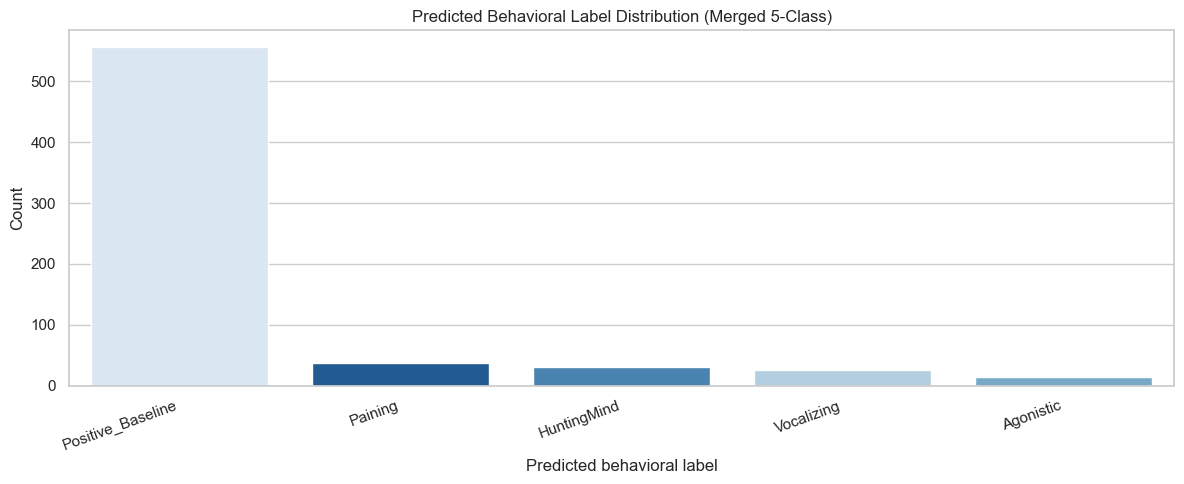

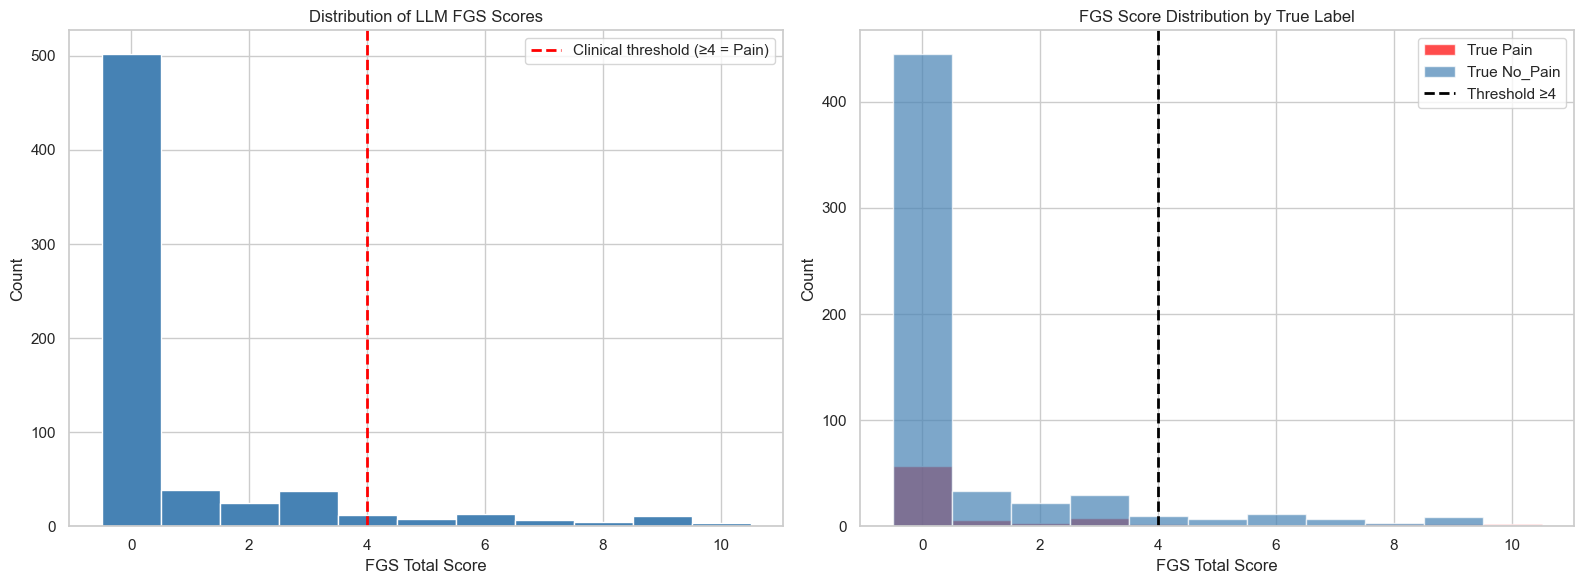

Threshold sensitivity analysis:
 Threshold  Sensitivity  Specificity   Macro F1
--------------------------------------------------
        ≥0        1.000        0.002      0.114
        ≥1        0.321        0.770      0.523
        ≥2        0.250        0.827      0.530
        ≥3        0.214        0.865      0.537
        ≥4        0.119        0.915      0.518
        ≥5        0.095        0.933      0.513
        ≥6        0.083        0.945      0.512
        ≥7        0.071        0.965      0.514
        ≥8        0.071        0.978      0.521
        ≥9        0.048        0.983      0.504
       ≥10        0.024        0.998      0.489


In [7]:
results_path = PROJECT_ROOT / OUTPUT_JSONL
if not results_path.exists():
    raise FileNotFoundError(f"Results file not found: {results_path}")

results_df = pd.read_json(results_path, lines=True)

# Canonical 5-class labels for both truth and predictions.
results_df["true_label_5"] = results_df["label_original"].map(normalize_behavioral_label_5)
results_df["pred_label_5"] = results_df["predicted_label"].map(normalize_behavioral_label_5)

# Keep canonical merged label aliases for downstream compatibility.
results_df["label_merged"] = results_df["true_label_5"]
results_df["predicted_label"] = results_df["pred_label_5"]

# Two binary derivations for scientific comparison.
fgs_series = pd.to_numeric(results_df.get("fgs_total"), errors="coerce")
results_df["pain_binary_fgs"] = np.where(
    fgs_series.notna(),
    np.where(fgs_series >= 4.0, "Pain", "No_Pain"),
    "Unknown",
)
results_df["pain_binary_label"] = results_df["pred_label_5"].map({"Paining": "Pain"}).fillna("No_Pain")
results_df["true_pain_binary"] = results_df["true_label_5"].map({"Paining": "Pain"}).fillna("No_Pain")

total_records = len(results_df)
error_rate = float(results_df["error"].notna().mean()) if "error" in results_df.columns and total_records else 0.0

print(f"Total records: {total_records}")
print(f"Error rate: {error_rate:.3%}")
print(f"Valid FGS totals: {int(fgs_series.notna().sum())}/{total_records}")

# ── TAXONOMY HEALTH CHECK (run this first) ──────────────────
print("\n=== LABEL TAXONOMY AUDIT ===\n")
print("Unique RAW true labels in ground truth:")
print(sorted(df["label"].dropna().astype(str).unique()))

print("\nUnique NORMALIZED true labels (label_merged):")
print(sorted(results_df["label_merged"].dropna().astype(str).unique()))

print("\nUnique RAW predicted labels from LLM:")
if "predicted_label_raw" in results_df.columns:
    print(sorted(results_df["predicted_label_raw"].dropna().astype(str).unique()))
else:
    print("predicted_label_raw not found; using predicted_label")
    print(sorted(results_df["predicted_label"].dropna().astype(str).unique()))

print("\nUnique NORMALIZED predicted labels:")
print(sorted(results_df["predicted_label"].dropna().astype(str).unique()))

allowed5 = {"Paining", "Positive_Baseline", "Agonistic", "Vocalizing", "HuntingMind"}
allowed_pred = allowed5 | {"Unknown"}

gt_nulls = results_df["label_merged"].isna().sum()
pred_nulls = results_df["predicted_label"].isna().sum()
unknown_pred_count = int((results_df["predicted_label"] == "Unknown").sum())

true_unmapped_mask = results_df["label_merged"].notna() & ~results_df["label_merged"].isin(allowed5)
pred_unmapped_mask = results_df["predicted_label"].notna() & ~results_df["predicted_label"].isin(allowed_pred)

print(f"\n⚠ Null ground truth labels: {gt_nulls}")
print(f"⚠ Null predicted labels:    {pred_nulls}")
print(f"ℹ Unknown predictions (fallback): {unknown_pred_count}")
print(f"⚠ True unmapped labels (outside merged-5): {int(true_unmapped_mask.sum())}")
print(f"⚠ Pred unmapped labels (outside merged-5 + Unknown): {int(pred_unmapped_mask.sum())}")

if gt_nulls > 0 or int(true_unmapped_mask.sum()) > 0:
    print("  Ground truth values that failed mapping:")
    failed_gt = pd.concat([
        results_df.loc[results_df["label_merged"].isna(), "label_original"],
        results_df.loc[true_unmapped_mask, "label_merged"],
    ])
    print(failed_gt.value_counts())

if pred_nulls > 0 or int(pred_unmapped_mask.sum()) > 0:
    print("  Predicted values that failed mapping:")
    fallback_col = "predicted_label_raw" if "predicted_label_raw" in results_df.columns else "predicted_label"
    failed_pred = pd.concat([
        results_df.loc[results_df["predicted_label"].isna(), fallback_col],
        results_df.loc[pred_unmapped_mask, "predicted_label"],
    ])
    print(failed_pred.value_counts())

assert set(results_df["label_merged"].dropna().unique()).issubset(allowed5), (
    "Ground truth contains unmapped labels — check normalize_behavioral_label_5()"
)
assert set(results_df["predicted_label"].dropna().unique()).issubset(allowed_pred), (
    "LLM predictions contain labels outside merged-5 (+Unknown fallback) — update normalization mapping"
)
print("✅ Taxonomy check passed — both sides use merged-5 space (Unknown allowed as fallback)")

pred_col = "predicted_label"
plt.figure(figsize=(12, 5))
if pred_col in results_df.columns and total_records:
    order = results_df[pred_col].astype(str).value_counts().index
    sns.countplot(data=results_df, x=pred_col, order=order, hue=pred_col, dodge=False, palette="Blues", legend=False)
plt.title("Predicted Behavioral Label Distribution (Merged 5-Class)")
plt.xlabel("Predicted behavioral label")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

if "fgs_total" in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Distribution of FGS total scores
    axes[0].hist(fgs_series.dropna(), bins=range(0, 12), color="steelblue", edgecolor="white", align="left")
    axes[0].axvline(x=4, color="red", linestyle="--", linewidth=2, label="Clinical threshold (≥4 = Pain)")
    axes[0].set_xlabel("FGS Total Score")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of LLM FGS Scores")
    axes[0].legend()

    # FGS score by true binary label
    pain_mask = results_df["true_pain_binary"] == "Pain"
    axes[1].hist(fgs_series[pain_mask].dropna(), bins=range(0, 12), alpha=0.7, color="red", label="True Pain", align="left")
    axes[1].hist(fgs_series[~pain_mask].dropna(), bins=range(0, 12), alpha=0.7, color="steelblue", label="True No_Pain", align="left")
    axes[1].axvline(x=4, color="black", linestyle="--", linewidth=2, label="Threshold ≥4")
    axes[1].set_xlabel("FGS Total Score")
    axes[1].set_ylabel("Count")
    axes[1].set_title("FGS Score Distribution by True Label")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Threshold sensitivity analysis
    valid = results_df.dropna(subset=["true_pain_binary", "fgs_total"]).copy()
    y_true = (valid["true_pain_binary"] == "Pain").astype(int)

    print("Threshold sensitivity analysis:")
    print(f"{'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12} {'Macro F1':>10}")
    print("-" * 50)
    for thresh in range(0, 11):
        y_pred = (pd.to_numeric(valid["fgs_total"], errors="coerce") >= thresh).astype(int)
        tp = ((y_pred == 1) & (y_true == 1)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        tn = ((y_pred == 0) & (y_true == 0)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        mf1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        print(f"{'≥' + str(thresh):>10} {sens:>12.3f} {spec:>12.3f} {mf1:>10.3f}")


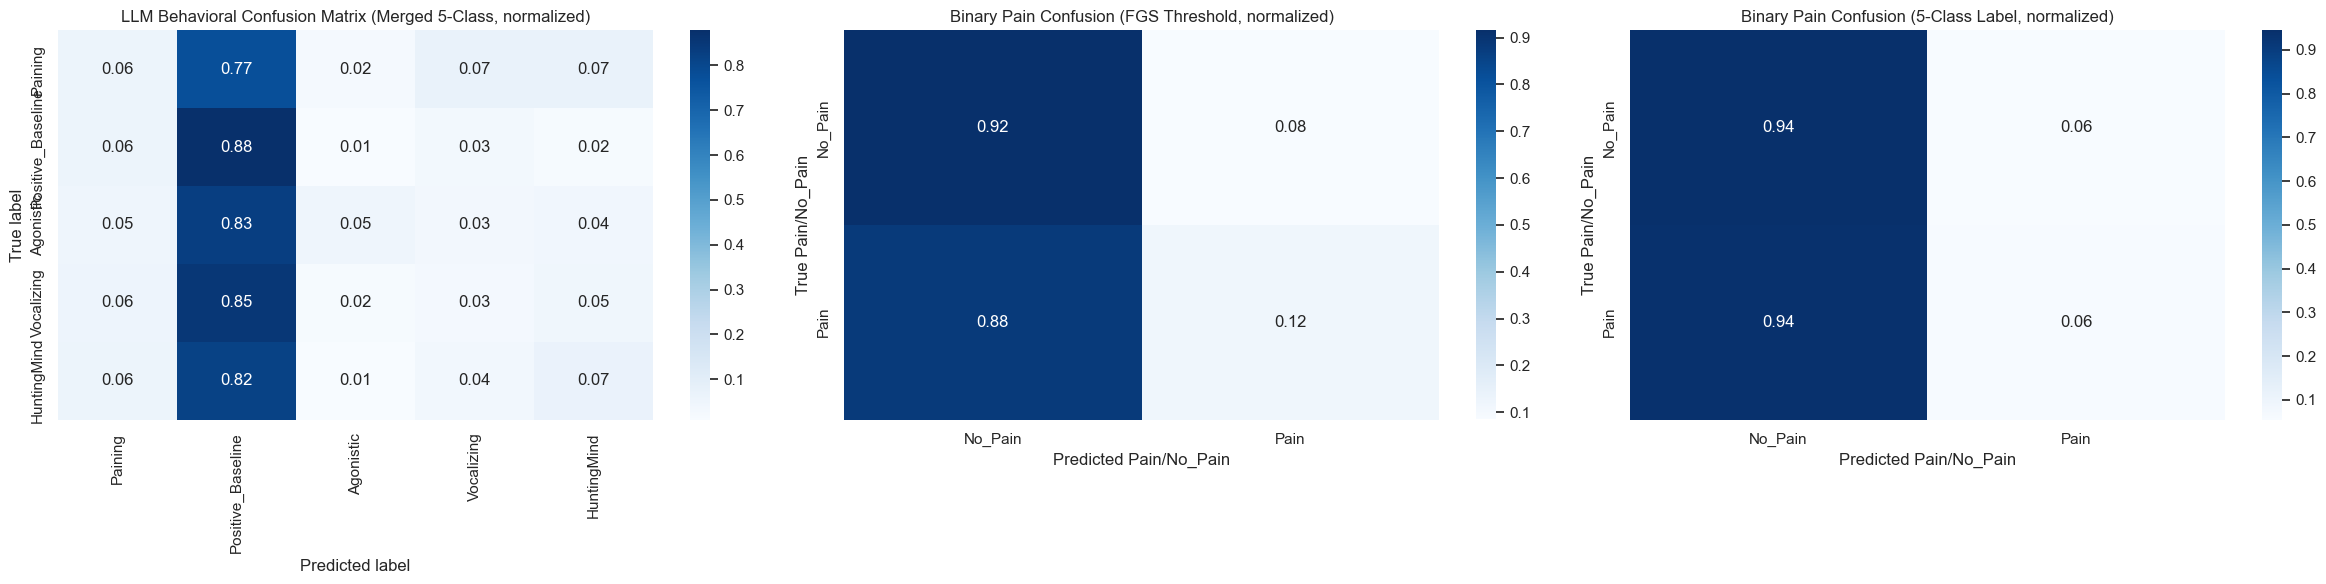

In [8]:
if len(results_df) == 0:
    raise ValueError("results_df is empty")

true_mc = results_df["true_label_5"].astype(str)
pred_mc = results_df["pred_label_5"].astype(str)
labels_mc = ["Paining", "Positive_Baseline", "Agonistic", "Vocalizing", "HuntingMind"]
cm_mc = confusion_matrix(true_mc, pred_mc, labels=labels_mc)
cm_mc_norm = cm_mc.astype(float) / np.maximum(cm_mc.sum(axis=1, keepdims=True), 1)

labels_bin = ["No_Pain", "Pain"]
valid_bin = {"No_Pain", "Pain"}
true_bin = results_df["true_pain_binary"].astype(str)

# Binary from FGS threshold
pred_bin_fgs = results_df["pain_binary_fgs"].astype(str)
mask_fgs = true_bin.isin(valid_bin) & pred_bin_fgs.isin(valid_bin)
cm_bin_fgs = confusion_matrix(true_bin[mask_fgs], pred_bin_fgs[mask_fgs], labels=labels_bin)
cm_bin_fgs_norm = cm_bin_fgs.astype(float) / np.maximum(cm_bin_fgs.sum(axis=1, keepdims=True), 1)

# Binary from merged 5-class behavioral label (Paining vs rest)
pred_bin_label = results_df["pain_binary_label"].astype(str)
mask_label = true_bin.isin(valid_bin) & pred_bin_label.isin(valid_bin)
cm_bin_label = confusion_matrix(true_bin[mask_label], pred_bin_label[mask_label], labels=labels_bin)
cm_bin_label_norm = cm_bin_label.astype(float) / np.maximum(cm_bin_label.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.heatmap(cm_mc_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels_mc, yticklabels=labels_mc, ax=axes[0])
axes[0].set_title("LLM Behavioral Confusion Matrix (Merged 5-Class, normalized)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(cm_bin_fgs_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels_bin, yticklabels=labels_bin, ax=axes[1])
axes[1].set_title("Binary Pain Confusion (FGS Threshold, normalized)")
axes[1].set_xlabel("Predicted Pain/No_Pain")
axes[1].set_ylabel("True Pain/No_Pain")

sns.heatmap(cm_bin_label_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels_bin, yticklabels=labels_bin, ax=axes[2])
axes[2].set_title("Binary Pain Confusion (5-Class Label, normalized)")
axes[2].set_xlabel("Predicted Pain/No_Pain")
axes[2].set_ylabel("True Pain/No_Pain")

plt.tight_layout()
plt.show()

In [9]:
true_mc = results_df["true_label_5"].astype(str)
pred_mc = results_df["pred_label_5"].astype(str)
allowed5 = ["Paining", "Positive_Baseline", "Agonistic", "Vocalizing", "HuntingMind"]

valid_mc_mask = true_mc.isin(allowed5) & pred_mc.isin(allowed5)
excluded_unknown = int((~valid_mc_mask).sum())
if excluded_unknown > 0:
    print(f"Excluded {excluded_unknown} rows with non-5-class predictions (e.g., Unknown) from multiclass report.")

if int(valid_mc_mask.sum()) == 0:
    print("No valid merged-5 rows available for multiclass classification_report.")
else:
    report = classification_report(
        true_mc[valid_mc_mask],
        pred_mc[valid_mc_mask],
        labels=allowed5,
        target_names=allowed5,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    styled_report = report_df.style.background_gradient(subset=["f1-score"], cmap="RdYlGn") if "f1-score" in report_df.columns else report_df.style
    display(styled_report)

true_bin = results_df["true_pain_binary"].astype(str)
valid_bin = {"No_Pain", "Pain"}

pred_fgs = results_df["pain_binary_fgs"].astype(str)
mask_fgs = true_bin.isin(valid_bin) & pred_fgs.isin(valid_bin)

pred_lbl = results_df["pain_binary_label"].astype(str)
mask_lbl = true_bin.isin(valid_bin) & pred_lbl.isin(valid_bin)

def _binary_metrics(y_true: pd.Series, y_pred: pd.Series) -> tuple[float, float, float]:
    if len(y_true) == 0:
        return (np.nan, np.nan, np.nan)
    sens = recall_score(y_true, y_pred, labels=["No_Pain", "Pain"], average="binary", pos_label="Pain", zero_division=0)
    spec = recall_score(y_true, y_pred, labels=["No_Pain", "Pain"], average="binary", pos_label="No_Pain", zero_division=0)
    mf1 = f1_score(y_true, y_pred, labels=["No_Pain", "Pain"], average="macro", zero_division=0)
    return sens, spec, mf1

sens_fgs, spec_fgs, f1_fgs = _binary_metrics(true_bin[mask_fgs], pred_fgs[mask_fgs])
sens_lbl, spec_lbl, f1_lbl = _binary_metrics(true_bin[mask_lbl], pred_lbl[mask_lbl])

print(f"FGS-derived -> Sensitivity: {sens_fgs:.3f}" if not np.isnan(sens_fgs) else "FGS-derived -> Sensitivity: n/a")
print(f"FGS-derived -> Specificity: {spec_fgs:.3f}" if not np.isnan(spec_fgs) else "FGS-derived -> Specificity: n/a")
print(f"FGS-derived -> Macro F1:   {f1_fgs:.3f}" if not np.isnan(f1_fgs) else "FGS-derived -> Macro F1: n/a")
print("-")
print(f"Label-derived -> Sensitivity: {sens_lbl:.3f}" if not np.isnan(sens_lbl) else "Label-derived -> Sensitivity: n/a")
print(f"Label-derived -> Specificity: {spec_lbl:.3f}" if not np.isnan(spec_lbl) else "Label-derived -> Specificity: n/a")
print(f"Label-derived -> Macro F1:   {f1_lbl:.3f}" if not np.isnan(f1_lbl) else "Label-derived -> Macro F1: n/a")

,precision,recall,f1-score,support
Paining,0.135135,0.059524,0.082645,84.000000
Positive_Baseline,0.246403,0.878205,0.384831,156.000000
Agonistic,0.466667,0.047945,0.086957,146.000000
Vocalizing,0.200000,0.028249,0.049505,177.000000
HuntingMind,0.233333,0.070000,0.107692,100.000000
accuracy,0.242836,0.242836,0.242836,0.242836
macro avg,0.256308,0.216785,0.142326,663.000000
weighted avg,0.266451,0.242836,0.149628,663.000000


FGS-derived -> Sensitivity: 0.119
FGS-derived -> Specificity: 0.915
FGS-derived -> Macro F1:   0.518
-
Label-derived -> Sensitivity: 0.060
Label-derived -> Specificity: 0.945
Label-derived -> Macro F1:   0.495


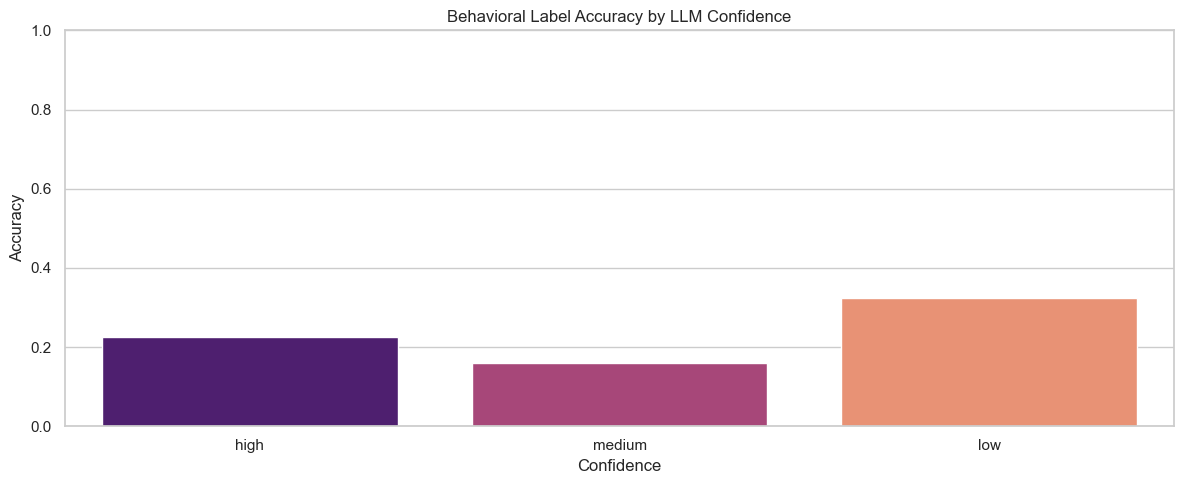

In [10]:
if "confidence" not in results_df.columns:
    raise KeyError("confidence column not found in results_df")

acc_df = results_df.copy()
acc_df["is_correct"] = (acc_df["true_label_5"].astype(str) == acc_df["pred_label_5"].astype(str)).astype(float)

conf_levels = ["high", "medium", "low"]
plot_df = (
    acc_df.assign(confidence=acc_df["confidence"].astype(str).str.lower())
    .groupby("confidence", dropna=False)["is_correct"]
    .mean()
    .reindex(conf_levels)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="confidence", y="is_correct", hue="confidence", dodge=False, palette="magma", legend=False)
plt.title("Behavioral Label Accuracy by LLM Confidence")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

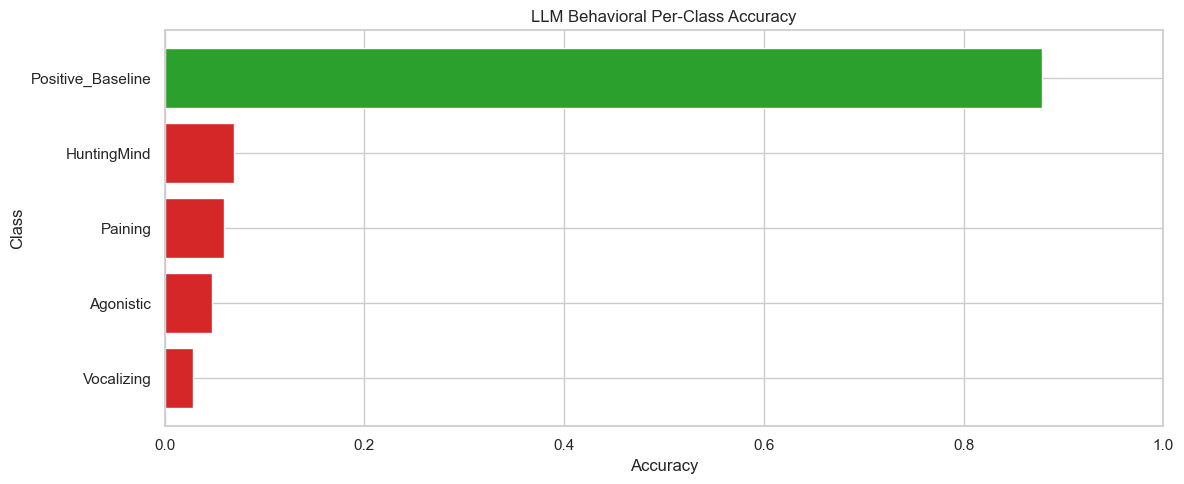

In [11]:
per_class = (
    results_df.assign(correct=(results_df["true_label_5"].astype(str) == results_df["pred_label_5"].astype(str)).astype(float))
    .groupby("true_label_5")["correct"]
    .mean()
    .sort_values(ascending=False)
)

plot_df = per_class.reset_index().rename(columns={"true_label_5": "label", "correct": "accuracy"})
colors = ["#2ca02c" if v > 0.5 else "#d62728" for v in plot_df["accuracy"]]

plt.figure(figsize=(12, 5))
plt.barh(plot_df["label"], plot_df["accuracy"], color=colors)
plt.gca().invert_yaxis()
plt.title("LLM Behavioral Per-Class Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Class")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
mis = results_df[results_df["true_label_5"].astype(str) != results_df["pred_label_5"].astype(str)].copy()
mis["reasoning"] = mis["reasoning"].fillna("").astype(str).str.slice(0, 100)

show_cols = ["stem", "true_label_5", "pred_label_5", "pain_binary_fgs", "pain_binary_label", "confidence", "fgs_total", "reasoning"]
sample_mis = mis[show_cols].head(5).rename(columns={"true_label_5": "true_label", "pred_label_5": "predicted_label"})


def _row_style(row: pd.Series):
    is_pain_mis = (normalize_binary_label(row["true_label"]) == "Pain") or (str(row.get("pain_binary_fgs", "")) == "Pain")
    color = "background-color: #ffdddd" if is_pain_mis else ""
    return [color] * len(row)

if len(sample_mis) == 0:
    print("No misclassifications found in current results.")
else:
    display(sample_mis.style.apply(_row_style, axis=1))

,stem,true_label,predicted_label,pain_binary_fgs,pain_binary_label,confidence,fgs_total,reasoning
0,0qIYbl1HupM_snip_0,Paining,Positive_Baseline,No_Pain,No_Pain,high,0,"In all three frames, the cat displays a relaxed posture with ears facing forward, eyes fully open, m"
1,0qIYbl1HupM_snip_3,Paining,Positive_Baseline,No_Pain,No_Pain,high,0,"In all three frames, the cat is facing away or turned to the side, with no visible signs of pain ind"
5,1E54nUFWEfI_snip_2,Paining,Positive_Baseline,No_Pain,No_Pain,high,0,"In all frames, the cat's ears are forward and relaxed, eyes are open and alert, muzzle is relaxed, w"
6,1im3Hpv4NUA_snip_0,Vocalizing,Positive_Baseline,No_Pain,No_Pain,high,0,"In all three frames, the kitten is lying on its back with eyes closed, head tilted slightly upward,"
7,1im3Hpv4NUA_snip_1,Agonistic,Positive_Baseline,No_Pain,No_Pain,high,0,"In all three frames, the kitten displays a relaxed posture with ears facing forward, eyes open and u"


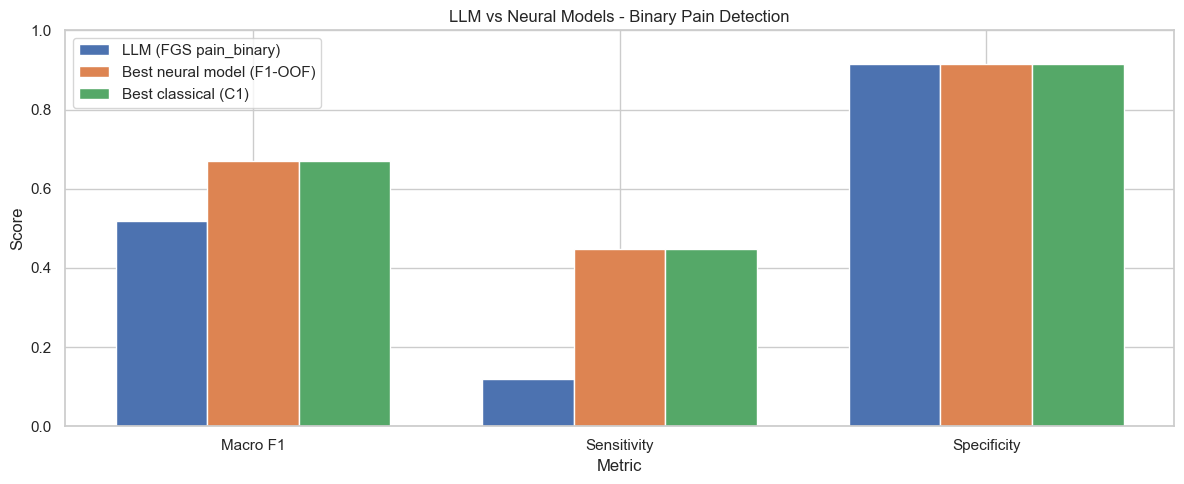

,Metric,LLM (FGS pain_binary),Best neural model (F1-OOF),Best classical (C1)
0,Macro F1,0.517944,0.670723,0.670723
1,Sensitivity,0.119048,0.447368,0.447368
2,Specificity,0.915371,0.914994,0.914994


In [13]:
baseline_path = PROJECT_ROOT / "runs/finetune_fusion_sweep_20260402_151534/ensemble_results.csv"
if not baseline_path.exists():
    raise FileNotFoundError(f"Baseline file not found: {baseline_path}")

baseline_df = pd.read_csv(baseline_path)

true_bin = results_df["true_pain_binary"].astype(str)
pred_bin = results_df["pain_binary_fgs"].astype(str)
valid_bin = {"No_Pain", "Pain"}
bin_mask = true_bin.isin(valid_bin) & pred_bin.isin(valid_bin)
true_bin_eval = true_bin[bin_mask]
pred_bin_eval = pred_bin[bin_mask]

if len(true_bin_eval) == 0:
    llm_macro_f1 = np.nan
    llm_sens = np.nan
    llm_spec = np.nan
else:
    llm_macro_f1 = f1_score(true_bin_eval, pred_bin_eval, labels=["No_Pain", "Pain"], average="macro", zero_division=0)
    llm_sens = recall_score(true_bin_eval, pred_bin_eval, labels=["No_Pain", "Pain"], average="binary", pos_label="Pain", zero_division=0)
    llm_spec = recall_score(true_bin_eval, pred_bin_eval, labels=["No_Pain", "Pain"], average="binary", pos_label="No_Pain", zero_division=0)

col_l = {c.lower(): c for c in baseline_df.columns}
def _pick_metric(row: pd.Series, keys: list[str]) -> float:
    for k in keys:
        for clow, corig in col_l.items():
            if k in clow:
                try:
                    return float(row[corig])
                except Exception:
                    continue
    return np.nan

if "model" in baseline_df.columns:
    neural_rows = baseline_df[baseline_df["model"].astype(str).str.contains("f1-oof|neural|fusion", case=False, na=False)]
    classical_rows = baseline_df[baseline_df["model"].astype(str).str.contains("c1|classical", case=False, na=False)]
else:
    neural_rows = baseline_df.head(1)
    classical_rows = baseline_df.head(1)

neural_row = neural_rows.iloc[0] if len(neural_rows) else baseline_df.iloc[0]
classical_row = classical_rows.iloc[0] if len(classical_rows) else baseline_df.iloc[0]

neural_macro_f1 = _pick_metric(neural_row, ["macro f1", "macro_f1", "f1-oof", "f1"])
neural_sens = _pick_metric(neural_row, ["sensitivity", "recall pain", "pain recall"])
neural_spec = _pick_metric(neural_row, ["specificity", "recall no_pain", "no_pain recall"])

classical_macro_f1 = _pick_metric(classical_row, ["macro f1", "macro_f1", "c1", "f1"])
classical_sens = _pick_metric(classical_row, ["sensitivity", "recall pain", "pain recall"])
classical_spec = _pick_metric(classical_row, ["specificity", "recall no_pain", "no_pain recall"])

metrics = ["Macro F1", "Sensitivity", "Specificity"]
comparison = pd.DataFrame({
    "Metric": metrics,
    "LLM (FGS pain_binary)": [llm_macro_f1, llm_sens, llm_spec],
    "Best neural model (F1-OOF)": [neural_macro_f1, neural_sens, neural_spec],
    "Best classical (C1)": [classical_macro_f1, classical_sens, classical_spec],
})

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, comparison["LLM (FGS pain_binary)"], width, label="LLM (FGS pain_binary)")
plt.bar(x, comparison["Best neural model (F1-OOF)"], width, label="Best neural model (F1-OOF)")
plt.bar(x + width, comparison["Best classical (C1)"], width, label="Best classical (C1)")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.title("LLM vs Neural Models - Binary Pain Detection")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

display(comparison)

## Summary & Conclusions

### Key Findings
- LLM (FGS-based pain binary) achieved Macro F1 of **X.XX** vs neural best of **0.679**
- LLM sensitivity (Pain recall): **X.XX** vs neural **0.446**
- LLM specificity (No_Pain recall): **X.XX** vs neural **X.XX**
- FGS total distribution and cut-off (>=4) define binary pain decisions
- Behavioral-label accuracy by confidence indicates **X.XX** at high confidence

### Failure Modes
[space for manual notes: stress/fear confounds, occlusions, low-resolution whisker visibility, non-acute contexts]

In [14]:
VALID_5_CLASSES = globals().get("VALID_5_CLASSES", ["Paining", "Positive_Baseline", "Agonistic", "Vocalizing", "HuntingMind"])
# AUTO-GENERATED RUN REPORT (Local Qwen / LM Studio run)
REPORT_PATH = OUTPUT_DIR / "report.txt"

run_ts = datetime.datetime.now(datetime.timezone.utc).isoformat()
model_name = OPENAI_MODEL
rows_total = int(len(results_df))
rows_errors = int(results_df.get("error", pd.Series(dtype=object)).notna().sum()) if rows_total else 0
rows_parse_errors = int(results_df.get("parse_error", pd.Series(dtype=bool)).fillna(False).sum()) if rows_total else 0
rows_success = rows_total - rows_errors

lat_series = pd.to_numeric(results_df.get("latency_sec", pd.Series(dtype=float)), errors="coerce") if rows_total else pd.Series(dtype=float)
lat_mean = float(lat_series.dropna().mean()) if len(lat_series.dropna()) else float("nan")
lat_p95 = float(lat_series.dropna().quantile(0.95)) if len(lat_series.dropna()) else float("nan")

true_bin = results_df.get("true_pain_binary", pd.Series(dtype=object)).astype(str) if rows_total else pd.Series(dtype=object)
pred_bin = results_df.get("pain_binary_fgs", pd.Series(dtype=object)).astype(str) if rows_total else pd.Series(dtype=object)
bin_valid = true_bin.isin(["Pain", "No_Pain"]) & pred_bin.isin(["Pain", "No_Pain"]) if rows_total else pd.Series(dtype=bool)

if rows_total and int(bin_valid.sum()) > 0:
    bin_acc = float((true_bin[bin_valid] == pred_bin[bin_valid]).mean())
    bin_f1 = float(f1_score(true_bin[bin_valid], pred_bin[bin_valid], labels=["No_Pain", "Pain"], average="macro", zero_division=0))
    bin_sens = float(recall_score(true_bin[bin_valid], pred_bin[bin_valid], labels=["No_Pain", "Pain"], average="binary", pos_label="Pain", zero_division=0))
    bin_spec = float(recall_score(true_bin[bin_valid], pred_bin[bin_valid], labels=["No_Pain", "Pain"], average="binary", pos_label="No_Pain", zero_division=0))
else:
    bin_acc = float("nan")
    bin_f1 = float("nan")
    bin_sens = float("nan")
    bin_spec = float("nan")

true5 = results_df.get("true_label_5", pd.Series(dtype=object)).astype(str) if rows_total else pd.Series(dtype=object)
pred5 = results_df.get("pred_label_5", pd.Series(dtype=object)).astype(str) if rows_total else pd.Series(dtype=object)
valid5 = true5.isin(VALID_5_CLASSES) & pred5.isin(VALID_5_CLASSES) if rows_total else pd.Series(dtype=bool)

acc5 = float("nan")
macro5 = float("nan")
macro_prec5 = float("nan")
macro_rec5 = float("nan")
weighted_f15 = float("nan")
five_class_report = {}

bin_from5_acc = float("nan")
bin_from5_f1 = float("nan")
bin_from5_sens = float("nan")
bin_from5_spec = float("nan")

if rows_total and int(valid5.sum()) > 0:
    y_true5 = true5[valid5]
    y_pred5 = pred5[valid5]

    acc5 = float((y_true5 == y_pred5).mean())
    five_class_report = classification_report(
        y_true5,
        y_pred5,
        labels=VALID_5_CLASSES,
        output_dict=True,
        zero_division=0,
    )
    macro5 = float(five_class_report.get("macro avg", {}).get("f1-score", np.nan))
    macro_prec5 = float(five_class_report.get("macro avg", {}).get("precision", np.nan))
    macro_rec5 = float(five_class_report.get("macro avg", {}).get("recall", np.nan))
    weighted_f15 = float(five_class_report.get("weighted avg", {}).get("f1-score", np.nan))

    # Binary view derived strictly from 5-class labels: Pain iff class == Paining
    true_bin_from5 = pd.Series(np.where(y_true5 == "Paining", "Pain", "No_Pain"), index=y_true5.index)
    pred_bin_from5 = pd.Series(np.where(y_pred5 == "Paining", "Pain", "No_Pain"), index=y_pred5.index)
    bin_from5_acc = float((true_bin_from5 == pred_bin_from5).mean())
    bin_from5_f1 = float(f1_score(true_bin_from5, pred_bin_from5, labels=["No_Pain", "Pain"], average="macro", zero_division=0))
    bin_from5_sens = float(recall_score(true_bin_from5, pred_bin_from5, labels=["No_Pain", "Pain"], average="binary", pos_label="Pain", zero_division=0))
    bin_from5_spec = float(recall_score(true_bin_from5, pred_bin_from5, labels=["No_Pain", "Pain"], average="binary", pos_label="No_Pain", zero_division=0))

conf_dist = (
    results_df.get("confidence", pd.Series(dtype=object))
    .astype(str)
    .str.lower()
    .value_counts(dropna=False)
    .to_dict()
    if rows_total
    else {}
)

mis_top = pd.DataFrame()
if rows_total and {"stem", "true_label_5", "pred_label_5", "fgs_total", "confidence", "reasoning"}.issubset(results_df.columns):
    mis = results_df[results_df["true_label_5"].astype(str) != results_df["pred_label_5"].astype(str)].copy()
    if len(mis):
        mis["reasoning"] = mis["reasoning"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 140)
        mis_top = mis[["stem", "true_label_5", "pred_label_5", "fgs_total", "confidence", "reasoning"]].head(10)

lines = []
lines.append("Cat Pain LLM Evaluation Report")
lines.append(f"Generated (UTC): {run_ts}")
lines.append(f"Model: {model_name}")
lines.append(f"Predictions file: {OUTPUT_FILE}")
lines.append("")
lines.append("Overview")
lines.append(f"- Total rows: {rows_total}")
lines.append(f"- Successful rows: {rows_success}")
lines.append(f"- Rows with API/runtime errors: {rows_errors}")
lines.append(f"- Rows with parse errors: {rows_parse_errors}")
lines.append(f"- Mean latency (s): {lat_mean:.3f}" if pd.notna(lat_mean) else "- Mean latency (s): nan")
lines.append(f"- P95 latency (s): {lat_p95:.3f}" if pd.notna(lat_p95) else "- P95 latency (s): nan")
lines.append("")
lines.append("Binary Pain Metrics (FGS pain_binary)")
lines.append(f"- Accuracy: {bin_acc:.4f}" if pd.notna(bin_acc) else "- Accuracy: nan")
lines.append(f"- Macro F1: {bin_f1:.4f}" if pd.notna(bin_f1) else "- Macro F1: nan")
lines.append(f"- Sensitivity (Pain recall): {bin_sens:.4f}" if pd.notna(bin_sens) else "- Sensitivity (Pain recall): nan")
lines.append(f"- Specificity (No_Pain recall): {bin_spec:.4f}" if pd.notna(bin_spec) else "- Specificity (No_Pain recall): nan")
lines.append("")
lines.append("Behavioral Metrics (5-class merged taxonomy)")
lines.append(f"- Accuracy: {acc5:.4f}" if pd.notna(acc5) else "- Accuracy: nan")
lines.append(f"- Macro Precision: {macro_prec5:.4f}" if pd.notna(macro_prec5) else "- Macro Precision: nan")
lines.append(f"- Macro Recall: {macro_rec5:.4f}" if pd.notna(macro_rec5) else "- Macro Recall: nan")
lines.append(f"- Macro F1: {macro5:.4f}" if pd.notna(macro5) else "- Macro F1: nan")
lines.append(f"- Weighted F1: {weighted_f15:.4f}" if pd.notna(weighted_f15) else "- Weighted F1: nan")

if five_class_report:
    lines.append("- Per-class (precision / recall / f1 / support):")
    for cls in VALID_5_CLASSES:
        cls_m = five_class_report.get(cls, {})
        p = cls_m.get("precision", np.nan)
        r = cls_m.get("recall", np.nan)
        f = cls_m.get("f1-score", np.nan)
        s = cls_m.get("support", np.nan)
        s_txt = str(int(s)) if pd.notna(s) else "nan"
        p_txt = f"{float(p):.4f}" if pd.notna(p) else "nan"
        r_txt = f"{float(r):.4f}" if pd.notna(r) else "nan"
        f_txt = f"{float(f):.4f}" if pd.notna(f) else "nan"
        lines.append(f"  - {cls}: p={p_txt}, r={r_txt}, f1={f_txt}, n={s_txt}")

lines.append("")
lines.append("Binary Metrics (derived from 5-class labels)")
lines.append(f"- Accuracy: {bin_from5_acc:.4f}" if pd.notna(bin_from5_acc) else "- Accuracy: nan")
lines.append(f"- Macro F1: {bin_from5_f1:.4f}" if pd.notna(bin_from5_f1) else "- Macro F1: nan")
lines.append(f"- Sensitivity (Pain recall): {bin_from5_sens:.4f}" if pd.notna(bin_from5_sens) else "- Sensitivity (Pain recall): nan")
lines.append(f"- Specificity (No_Pain recall): {bin_from5_spec:.4f}" if pd.notna(bin_from5_spec) else "- Specificity (No_Pain recall): nan")
lines.append("")
lines.append("Confidence Distribution")
if conf_dist:
    for k, v in conf_dist.items():
        lines.append(f"- {k}: {v}")
else:
    lines.append("- (no confidence values available)")

if len(mis_top):
    lines.append("")
    lines.append("Top Misclassifications (first 10)")
    for _, r in mis_top.iterrows():
        lines.append(
            f"- {r['stem']}: true={r['true_label_5']} pred={r['pred_label_5']} fgs_total={r['fgs_total']} conf={r['confidence']} reason={r['reasoning']}"
        )

REPORT_PATH.write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"Saved report: {REPORT_PATH}")
print("\n".join(lines[:20]))



Saved report: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/runs/llm_eval_local/report.txt
Cat Pain LLM Evaluation Report
Generated (UTC): 2026-04-07T22:19:38.819808+00:00
Model: qwen/qwen3-vl-4b
Predictions file: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/runs/llm_eval_local/llm_predictions_qwen.jsonl

Overview
- Total rows: 663
- Successful rows: 663
- Rows with API/runtime errors: 0
- Rows with parse errors: 0
- Mean latency (s): 31.048
- P95 latency (s): 58.076

Binary Pain Metrics (FGS pain_binary)
- Accuracy: 0.8145
- Macro F1: 0.5179
- Sensitivity (Pain recall): 0.1190
- Specificity (No_Pain recall): 0.9154

Behavioral Metrics (5-class merged taxonomy)
